# Análisis Exploratorio de nuestro Corpus

Una vez creada la base de datos con Web-Scrapping y utilizando el libro en formato .epub para crear los chunks, vamos a realizar un análisis exploratorio a nuestro corpus.

Hemos decidido que no se va a preprocesar nada del corpus, pues un libro ya tiene la estructura necesaria para que sea entendible. Además, tratandose de un RAG, si preprocesamos quitando StopWords, puntuaciones, mayúsculas... perderíamos el sentido del texto. Como la idea de un RAG es enviar chunks como contexto para que un LLM conteste, carece de sentido empeorar la comprensión del texto dentro de esos chunks.

Una vez aclarado el porqué no hacemos preprocesamiento, vamos a hacer el EDA.



In [1]:
!pip install emoji langdetect keybert sentence-transformers umap-learn -q
!pip install opentelemetry-api==1.25.0 opentelemetry-sdk==1.25.0 opentelemetry-exporter-otlp-proto-grpc==1.25.0 -q
!pip install chromadb --upgrade -q
!pip install gensim -q
!pip install pyLDAvis -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.4 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.0/107.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 9.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-pubsub 2.37.0 requires opentelemetry-api>=1.27.0, but you have opentelemetry-api 1.25.0 which is incompatible.
google-cloud-

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import emoji
import re
from collections import Counter
import matplotlib.pyplot as plt
import os
import random

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from nltk.util import ngrams

from sklearn.ensemble import IsolationForest
from sklearn.metrics.pairwise import cosine_distances
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances

from langdetect import detect, DetectorFactory
from keybert import KeyBERT
import umap

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)

from gensim import corpora
from gensim.models import LsiModel, LdaModel, HdpModel, LdaMulticore
np.random.seed(SEED)
from gensim.models import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import chromadb
from pathlib import Path

DB_PATH_RESUMENES = Path("/content/drive/MyDrive/NLP_PRACTICA/Persist/chroma_db_resumenes_qwen")
DB_PATH_LIBRO = "/content/drive/MyDrive/NLP_PRACTICA/Persist/libro_largo_qwen"
client_libro = chromadb.PersistentClient(path=DB_PATH_LIBRO)
coll_name_libro = client_libro.list_collections()[0].name

collection_libro = client_libro.get_collection(coll_name_libro)
COLLECTION_NAME = "resumenes_got"

client = chromadb.PersistentClient(path=str(DB_PATH_RESUMENES))
collection = client.get_collection(COLLECTION_NAME)

In [5]:
data = collection.get()
data_libro = collection_libro.get()

df_resumenes = pd.DataFrame({
    'ids': data['ids'],
    'documents': data['documents'],
    'metadatas': data['metadatas']
})

if df_resumenes['metadatas'].notnull().any():
    df_meta = pd.json_normalize(df_resumenes['metadatas'])
    df_resumenes = pd.concat([df_resumenes.drop('metadatas', axis=1), df_meta], axis=1)


df_libro = pd.DataFrame({
    'ids': data_libro['ids'],
    'documents': data_libro['documents'],
    'metadatas': data_libro['metadatas']
})

if df_libro['metadatas'].notnull().any():
    df_meta_libro = pd.json_normalize(df_libro['metadatas'])
    df_libro = pd.concat([df_libro.drop('metadatas', axis=1), df_meta_libro], axis=1)

df = pd.concat([df_resumenes, df_libro], ignore_index=True)

print(f"Total registros en df: {len(df)}")
display(df_libro.head(5))
display(df_resumenes.head(5))

Total registros en df: 648


,ids,documents,characters,keywords,houses,main_event,chapter_title,chunk_index,chapter_order,chapter_id,locations,pov
0,agot_001_bran_0,Chapter: BRAN (1)\nChapter order: 1\nPOV: BRAN...,"Bran, Robb, Jon Nieve, Eddard Stark, Theon Gre...","decapitación, justicia, rey, salvajes, Mance R...","Stark, Greyjoy, Baratheon",Bran presencia la decapitación de un hombre ac...,BRAN (1),0,1,agot_001_bran,"Invernalia, el fortín de las colinas, el puente",BRAN
1,agot_001_bran_1,Chapter: BRAN (1)\nChapter order: 1\nPOV: BRAN...,"Bran, Robb, Jon, Jory, Theon Greyjoy, Hullen","Bran, Robb, Jon, lobos huargos, nieve, Muro, S...","Stark, Greyjoy",Bran y su hermano Robb encuentran lobos huargo...,BRAN (1),1,1,agot_001_bran,"el norte del reino, el puente, el Muro",BRAN
2,agot_001_bran_2,Chapter: BRAN (1)\nChapter order: 1\nPOV: BRAN...,"Bran, Jory, Robb, Jon, Hullen, Theon Greyjoy, ...","Bran, Jon, cachorros, lobos, Stark, Greyjoy, I...","Stark, Greyjoy",Bran y sus hermanos reciben cinco cachorros de...,BRAN (1),2,1,agot_001_bran,"Invernalia, el norte",BRAN
3,agot_002_catelyn_0,Chapter: CATELYN (1)\nChapter order: 2\nPOV: C...,"Catelyn, Ned, Bran, Arya, Sansa, Rickon","Catelyn, Ned, Bosque de dioses, Aguasdulces, I...","Tully, Stark",Catelyn se reúne con su esposo Ned en el bosqu...,CATELYN (1),0,2,agot_002_catelyn,"Aguasdulces, Invernalia, El bosque de dioses, ...",CATELYN
4,agot_002_catelyn_1,Chapter: CATELYN (1)\nChapter order: 2\nPOV: C...,,,,,CATELYN (1),1,2,agot_002_catelyn,,CATELYN


,ids,documents,paragraph_id,chapter
0,Juego_de_Tronos-Prólogo_0,"Dos hombres de la Guardia de la Noche , Will y...",0,Juego de Tronos-Prólogo
1,Juego_de_Tronos-Prólogo_1,"Will le lleva allí, dejando atrás Gared para p...",1,Juego de Tronos-Prólogo
2,Juego_de_Tronos-Capítulo_1_0,"Bran viaja con su padre, Lord Eddard Stark , y...",0,Juego de Tronos-Capítulo 1
3,Juego_de_Tronos-Capítulo_1_1,"De camino a Invernalia , Robb y Jon discuten s...",1,Juego de Tronos-Capítulo 1
4,Juego_de_Tronos-Capítulo_1_2,Jon les alcanza para que vean lo que Robb y él...,2,Juego de Tronos-Capítulo 1


En las celdas de arrnia, hemos cargado las dos colecciones que tenemos: la de los resúmenes obtenidas por WebScrapping, y la del libro original de Juego de Tronos. Para facilitar el análisis, hemos creado tres DataFrames:
- El del libro
- El de los resúmenes
- El total

A continuación, empecemos primero con los chunks del libro:

In [6]:
df_libro.shape

(328, 12)

In [7]:
df_libro.columns

Index(['ids', 'documents', 'characters', 'keywords', 'houses', 'main_event',
       'chapter_title', 'chunk_index', 'chapter_order', 'chapter_id',
       'locations', 'pov'],
      dtype='str')

In [8]:
df_libro.info()

<class 'pandas.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ids            328 non-null    str  
 1   documents      328 non-null    str  
 2   characters     328 non-null    str  
 3   keywords       328 non-null    str  
 4   houses         328 non-null    str  
 5   main_event     328 non-null    str  
 6   chapter_title  328 non-null    str  
 7   chunk_index    328 non-null    int64
 8   chapter_order  328 non-null    int64
 9   chapter_id     328 non-null    str  
 10  locations      328 non-null    str  
 11  pov            328 non-null    str  
dtypes: int64(2), str(10)
memory usage: 2.0 MB


Como vemos, tenemos 328 chunks en la colección del libro, no tenemos ningún NaN, y tenemos 12 columnas gracias a los metadatos que le hemos introducido a los chunks a la hora de crear la colección. Las columnas son las siguientes:

- id: Identificador del documento
- documents: el texto del libro
- main_event: un breve resumen de lo que pasa en ``documents`` generado por un LLM de forma automática
- chapter_order: el capítulo al que pertenece el texto
- pov: punto de vista
- chapter_title: título del capítulo
- keywords: palabras clave del texto extraidas por un LLM de forma automática
- locations: localizaciones mencionadas en el texto extraídas por un LLM de forma automática
- houses: casas del mundo de Juego de Tronos mencionadas en el texto
- chunk_index: id que identifica el chunk
- characters: personajes que aparecen en el texto extraidos con un LLM de forma automática.

Por otro lado, en la colección de los resúmenes tenemos lo siguiente:

In [9]:
df_resumenes.shape

(320, 4)

In [10]:
df_resumenes.columns

Index(['ids', 'documents', 'paragraph_id', 'chapter'], dtype='str')

In [11]:
df_resumenes.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ids           320 non-null    str  
 1   documents     320 non-null    str  
 2   paragraph_id  320 non-null    int64
 3   chapter       320 non-null    str  
dtypes: int64(1), str(3)
memory usage: 227.7 KB


En esta ocasión tenemos 320 entradas con cuatro columnas sin ningún valor vacio. Cada una de las entradas es un parrafo del resumen obtenido por WebScrapping. Es decir, si el resumen de un capítulo tenía 4 parrafos, habrá 4 chunks de ese capítulo. Las columnas que componen esta colección son:

- ids: identificador del chunks
- documents: el parrafo con el resumen
- paragraph_id: qué parrafo es dentro de un mismo capítulo
- chapter: el capítulo del que sacamos el resumen

Para hacer el EDA, hay columnas que no aportan apenas valor, por lo tanto, vamos a eliminar algunas columnas:

In [12]:
df_libro.drop(columns=['ids', 'chunk_index'], inplace=True)
df_resumenes.drop(columns=['ids','paragraph_id'], inplace=True)
df.drop(columns=['ids','paragraph_id','chunk_index'], inplace=True)

Continuemos con el EDA viendo cuantos valores únicos hay y si hay algún duplicado:

In [13]:
df.nunique()

documents        648
chapter           73
characters       215
keywords         215
houses           112
main_event       215
chapter_title     72
chapter_order     72
chapter_id        72
locations        205
pov                8
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

Vemos que no hay ningún duplicado, que tenemos en total 648 documentos, 73 capítulos contando el prólogo, 215 entradas con ``main_event``, 8 puntos de vista, 215 entradas con ``keywords``, 205 localizaciones, 112 entradas con casas del mundo y 215 entradas con personajes.

De aquí se puede inferir que, a la hora de crear los chunks, el LLM no ha sido capaz de conseguir el main_event o los personajes de algunas de las entradas, pues si tenemos 328 chunks del libro, deberíamos tener 328 entradas con ``main_event``.

Ahora, veamos la distibución de los POV y como se distribuye el texto en ellos:


pov
EDDARD      62
CATELYN     54
DAENERYS    51
TYRION      44
JON         39
BRAN        30
SANSA       26
ARYA        22
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='pov'>

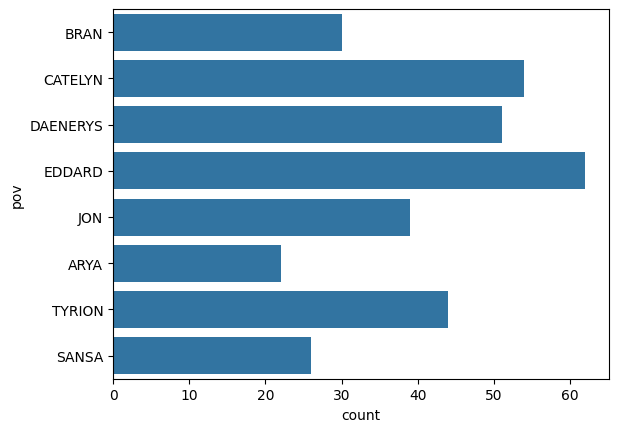

In [15]:
display(df["pov"].value_counts())

sns.countplot(df['pov'])

Como vemos, el personaje que más chunks (y por consiguiente más capítulos) es Eddard, el protagonista de la novela, seguido de Catelyn, su esposa y Tyrion, miembro de la familia rival. Ahora, veamos como son los capítulos en función del pov:


In [16]:
def word_count(text):
    tokens = re.findall(r'\w+', str(text))
    return len(tokens)

df['word_count']=df['documents'].apply(word_count)

pov
ARYA        1066.045455
BRAN        1057.433333
CATELYN      964.796296
DAENERYS    1014.823529
EDDARD       978.209677
JON         1070.538462
SANSA       1013.346154
TYRION       994.522727
Name: word_count, dtype: float64

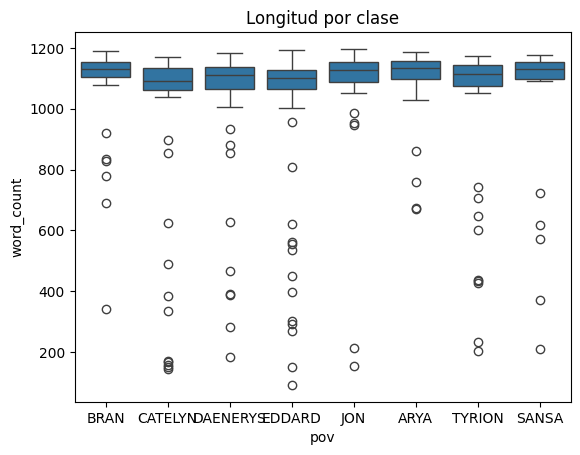

In [17]:
display(df.groupby('pov')['word_count'].mean())


sns.boxplot(data=df, x="pov", y="word_count")
plt.title("Longitud por clase")
plt.show()

Como era de esperar, la mayoría de chunks tienen una longitud parecida de media, porque a la hora de crearlos habíamos puesto que llegasen a unos 6000 caracteres. Los outliers son cunks que se crearon cuando el capítulo estaba a punto de acabarse. Un análisis más inteligente sería si lo hicieramos por capítulo y POV, en vez de solo por capítulo:

Longitud media del capítulo por POV:


pov
ARYA        4690.600000
BRAN        4531.857143
CATELYN     4736.272727
DAENERYS    5175.600000
EDDARD      4043.266667
JON         4639.000000
SANSA       4391.166667
TYRION      4862.111111
Name: word_count, dtype: float64

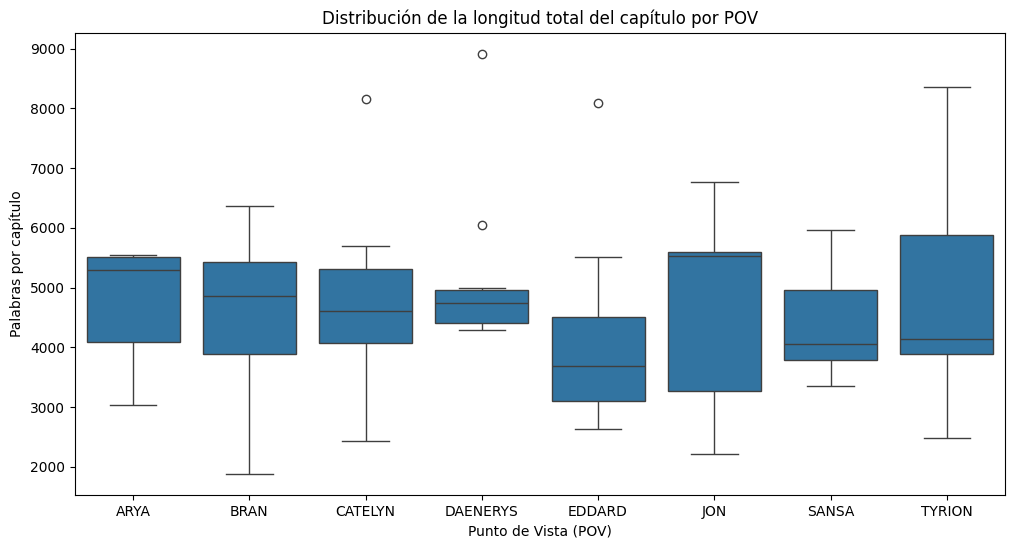

In [18]:
df_capitulos = df.groupby(['chapter_title', 'pov'])['word_count'].sum().reset_index()

print("Longitud media del capítulo por POV:")
display(df_capitulos.groupby('pov')['word_count'].mean())

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_capitulos, x="pov", y="word_count")
plt.title("Distribución de la longitud total del capítulo por POV")
plt.ylabel("Palabras por capítulo")
plt.xlabel("Punto de Vista (POV)")
plt.show()

Como vemos, el personaje con los capítulos más largos de media es Daenerys, con una media de 5175 palabras por capítulo. Tyrion es el personaje con la distribución más grande, con capítulos que van desde las 3000 palabras hasta uno que llega a casi las 9000.

Sigamos viendo qué casas aparecen en el corpus y en qué frecuencia:

Frecuencia de las casas mencionadas:


,Casa,Frecuencia
0,Stark,126
4,Lannister,122
5,Targaryen,52
8,Arryn,24
3,Tully,22
7,Dothraki,21
2,Baratheon,20
11,Mormont,15
1,Greyjoy,12
27,Frey,9


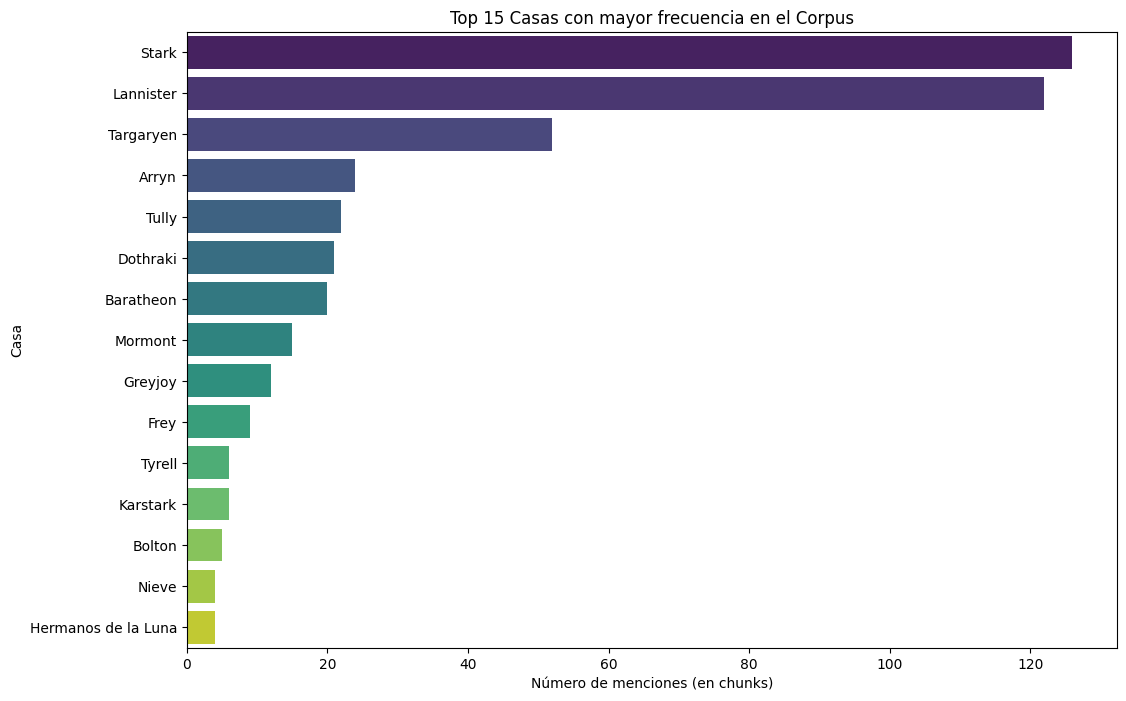

In [19]:
houses_list = []
for h in df['houses'].dropna():
    if isinstance(h, str):
        parts = [p.strip() for p in h.split(',') if p.strip()]
        houses_list.extend(parts)
    elif isinstance(h, list):
        houses_list.extend(h)

house_counts = Counter(houses_list)
df_houses = pd.DataFrame(house_counts.items(), columns=['Casa', 'Frecuencia']).sort_values(by='Frecuencia', ascending=False)

print("Frecuencia de las casas mencionadas:")
display(df_houses.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(data=df_houses.head(15), x='Frecuencia', y='Casa', palette='viridis')
plt.title('Top 15 Casas con mayor frecuencia en el Corpus')
plt.xlabel('Número de menciones (en chunks)')
plt.ylabel('Casa')
plt.show()

Como vemos, las tres casas más mencionadas son Stark, Lannister y Targaryen. Es decir, las casas protagonistas. La casa Arryn también aparece mucho en este libro, ya que durante el cautiverio de Tyrion Lannister en el Nido de Águilas se menciona mucho.

A continuación, veamos como se distribuye el número de palabras en el dataframe:

<Axes: title={'center': 'Distribución de la longitud de las descripciones'}, xlabel='Número de palabras por descripción', ylabel='Frecuencia'>

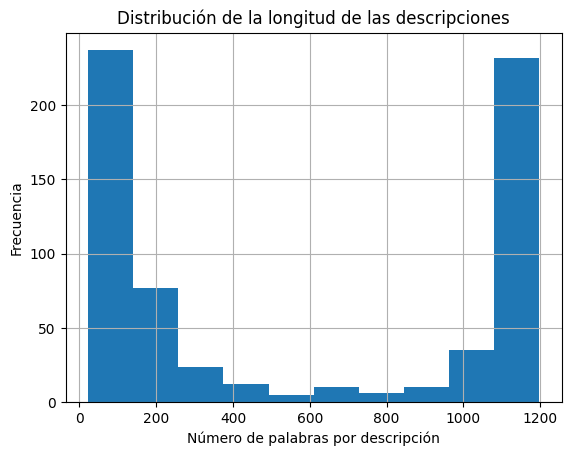

In [20]:
plt.xlabel('Número de palabras por descripción')
plt.ylabel('Frecuencia')
plt.title('Distribución de la longitud de las descripciones')

df['word_count'].hist()

Como esperabamos, tenemos una U. La parte de la izquierda pertenece a la colección de los resuemens, mientras que la parte derecha pertenece a la colección de los libros. Ahora, veamos como de rico es en palabras cada POV en general:

In [21]:
df['unique_word_count'] =df['documents'].apply(lambda x: len(set(str(x).split())))

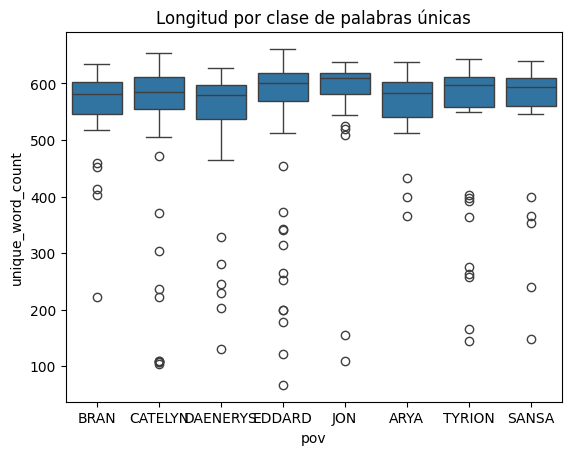

In [22]:
df.groupby('pov')['unique_word_count'].mean()

sns.boxplot(data=df, x="pov", y="unique_word_count")
plt.title("Longitud por clase de palabras únicas")
plt.show()

In [23]:
df.groupby('pov')["unique_word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
pov,,,,,,,,
ARYA,22.0,558.000000,72.224518,366.0,540.50,582.5,601.75,638.0
BRAN,30.0,554.300000,87.564026,222.0,545.25,580.5,602.00,635.0
CATELYN,54.0,523.111111,160.348402,104.0,555.00,585.0,610.50,654.0
DAENERYS,51.0,535.274510,118.139930,130.0,536.50,580.0,596.50,628.0
EDDARD,62.0,539.741935,148.490209,67.0,568.25,600.5,617.75,661.0
JON,39.0,575.025641,109.188752,109.0,582.00,609.0,619.00,638.0
SANSA,26.0,539.692308,127.496437,149.0,559.25,593.0,608.75,639.0
TYRION,44.0,538.386364,132.963400,144.0,558.50,597.0,610.50,644.0


Vemos que, de media, cada pov tiene como normal general 550 pálabras únicas por entrada.

Continuamos con el type-token ratio o ttr, una medida habitual para cuantificar la diversidad léxica estructural de un texto. Este ratio se mide entre 0 y 1 y se calcula como:

$\frac{Número de palabras únicas}{número total de palabras} = TTR$

Si está proximo a 1, significa que tenemos un vocabulario variado con pocas repeticiones. En cambio, si se acerca  0.5, tenemos mucho vocabulario repetido.

El problema es que, al ser un corpus tan pequeño, el TTR suele ser artificialmente alto, ya que no hay texto suficiente para que suceda la repetición natural del vocabulario.

También tenemos un solapamiento fuerte, lo que significa que las clases no están claramente separadas.

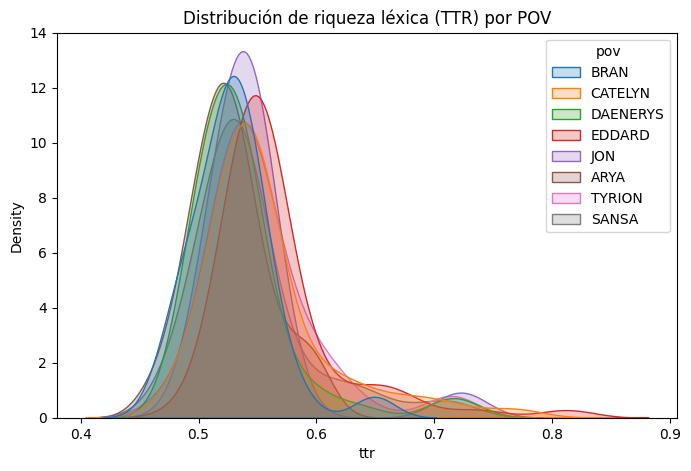

In [24]:
df['ttr'] = df['unique_word_count'] / df['word_count']

plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="ttr", hue="pov", fill=True, common_norm=False)
plt.title("Distribución de riqueza léxica (TTR) por POV")
plt.show()


Como vemos, están centradas en el 0.55, aunque luego tienen algún pico un poco más alejado de esos valores. Esto indica que George R.R.Martin escribe de forma consistente, usando un vocabulario parecido a lo largo de la obra.

También vemos que EDDARD, el rojo, llega a 0.8. Es decir, este sería el personaje con mayor riqueza léxica. Y es verdad que, aunque breve, EDDARD es un personaje realmente complejo, con sus constantes dudas entre el honor y el deber.

Una vez visto un análisis grámatical breve, vamos a ver algunas estadísticas de nuestros textos:

- Puntiaciones
- Emoticonos
- Mayúsculas
- URLS
- Menciones (@)

In [25]:
# emojis por review
df['emoji_count'] = df['documents'].apply(lambda x: emoji.emoji_count(str(x)))

# mayúsculas por review
df['caps_ratio'] = df['documents'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if len(str(x)) > 0 else 0)

# url por review
df['has_url'] = df['documents'].apply(lambda x: int(bool(re.search(r'http[s]?://\S+', str(x)))))

# mentions por review
df['has_mention'] = df['documents'].apply(lambda x: int(bool(re.search(r'@\S+', str(x)))))

# puntuaciones por review
df['punct_density'] = df['documents'].apply(lambda x: len(re.findall(r'[!?.¡¿,;:]', str(x))) / len(str(x)) if len(str(x)) > 0 else 0)



In [26]:
global_stats = df[['emoji_count', 'caps_ratio', 'has_url', 'has_mention', 'punct_density']].mean()
print("Promedio global de estilo del corpus:\n", global_stats)

Promedio global de estilo del corpus:
 emoji_count      0.000000
caps_ratio       0.033162
has_url          0.000000
has_mention      0.000000
punct_density    0.026185
dtype: float64


Vemos que no hay ningún emoticono, hay un 3% de mayúsculas y un 2% de signos de puntuación.


A continuación, sigamos con la distribución de las palabras en nuestro corpus.

Empecemos por analizar el ranking de las palabras más frecuentes. Como sabemos por la teoria, en principio la segunda palabra más común debería aparece la mitad de la veces que la más común. La tercera palabra más común debería aparece un terciod e las veces que la más común... y así sucesivamente.

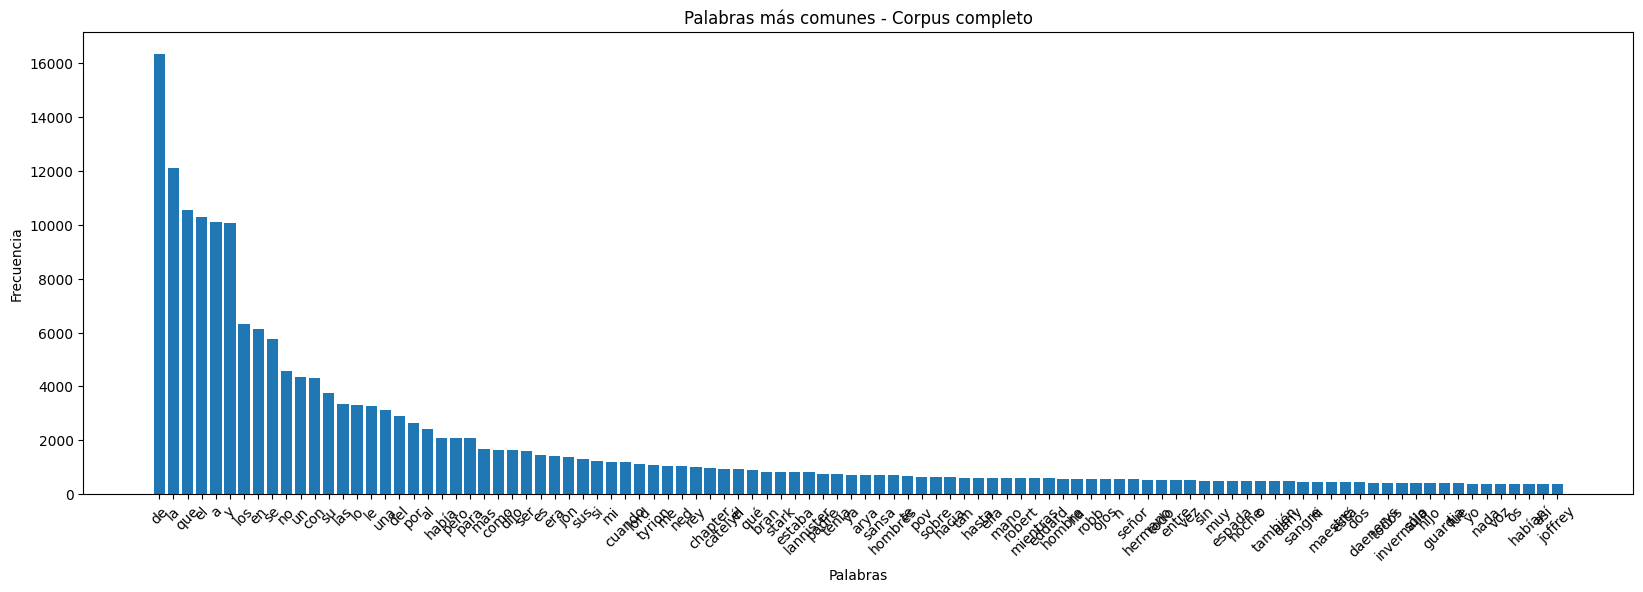

In [27]:
# Unir todos los textos
texts = df["documents"]

# Tokenización
words = [
    w for text in texts
    for w in re.findall(r"\b\w+\b", text.lower())
]

# Conteo global
word_counts = Counter(words)

# Top 10 global
top_words = word_counts.most_common(100)

# Separar palabras y frecuencias
words, counts = zip(*top_words)

# Plot
plt.figure(figsize=(20, 6))
plt.bar(words, counts)

plt.title("Palabras más comunes - Corpus completo")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45)
plt.show()


Como era de esperar, la mayoría de las palabras del principio son StopWords, es decir, palabras que sirven para dar contexto pero que por sí solas no aportan nada. Por eso mismo, vamos a eliminar esas palabras del corpus para ver como cambia la distribución. No obstante, a simple vista, sí que parece que se cumpla la ley de Zipf.

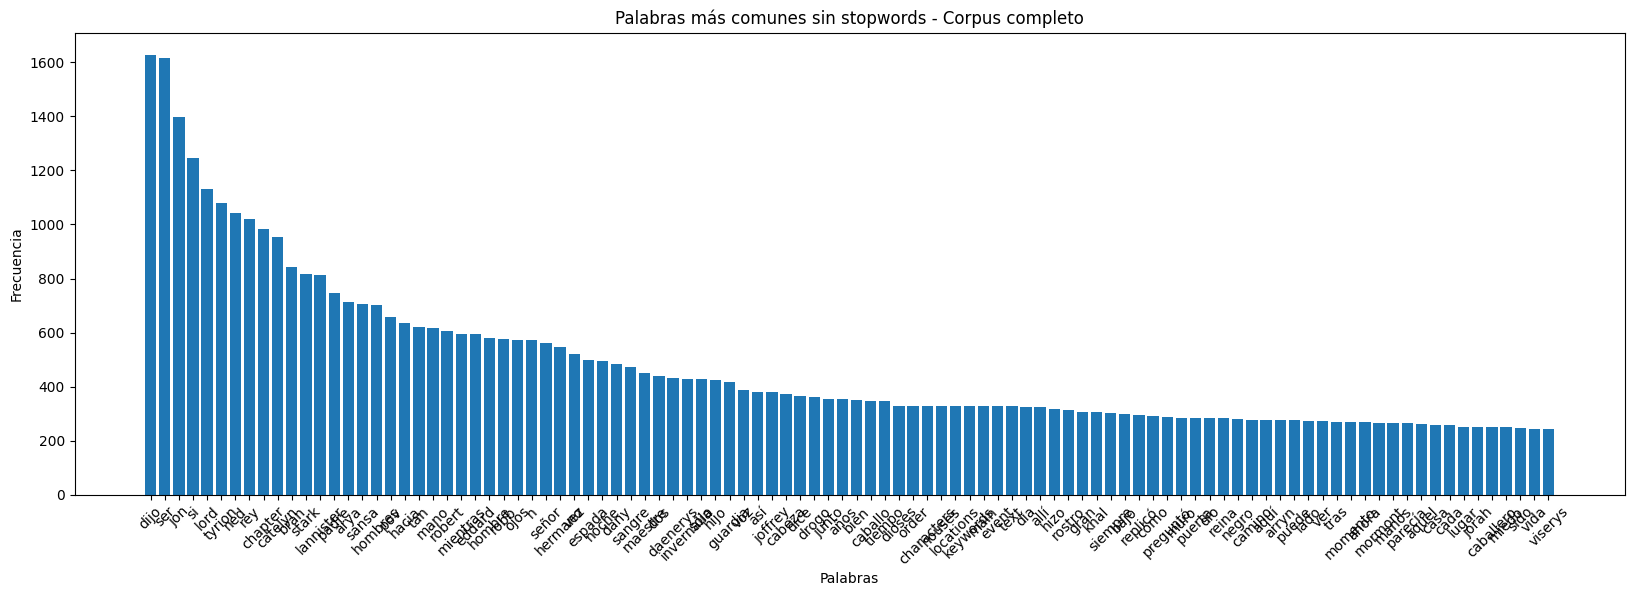

[('dijo', 1629), ('ser', 1618), ('jon', 1397), ('si', 1245), ('lord', 1132), ('tyrion', 1079), ('ned', 1041), ('rey', 1021), ('chapter', 984), ('catelyn', 953), ('bran', 843), ('stark', 817), ('lannister', 813), ('padre', 747), ('arya', 714), ('sansa', 705), ('hombres', 702), ('pov', 656), ('hacia', 634), ('tan', 622), ('mano', 618), ('robert', 606), ('mientras', 596), ('eddard', 593), ('hombre', 579), ('robb', 576), ('ojos', 572), ('n', 571), ('señor', 561), ('hermano', 548)]


In [28]:
stop_words = set(stopwords.words('spanish'))

texts = df["documents"]

words = [
    w for text in texts
    for w in re.findall(r"\b\w+\b", text.lower())
    if w not in stop_words
]


word_counts = Counter(words)

top_words = word_counts.most_common(100)

words_plot, counts = zip(*top_words)

plt.figure(figsize=(20, 6))
plt.bar(words_plot, counts)

plt.title("Palabras más comunes sin stopwords - Corpus completo")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45)
plt.show()

top_words = word_counts.most_common(30)

print(top_words)

Como vemos, ahora las palabras más comunes son palabras del contexto: ser, lord, nombres  de los personajes, rey...  Ahora veamos lo mismo pero en función del POV:

In [29]:
stop_words = set(stopwords.words('spanish'))

# Crear la nueva columna sin stopwords
df['documents_sin_stop'] = df['documents'].apply(
    lambda x: " ".join([w for w in re.findall(r"\b\w+\b", str(x).lower()) if w not in stop_words])
)

rankings = {}

for label in df["pov"].unique():
    if pd.isna(label):
        continue
    texts = df[df["pov"] == label]["documents_sin_stop"]
    words = [word for text in texts for word in text.split()]
    word_counts = Counter(words)
    rankings[label] = word_counts.most_common(10)

rankings

{'BRAN': [('bran', 569),
  ('robb', 202),
  ('dijo', 169),
  ('maestre', 121),
  ('padre', 118),
  ('luwin', 110),
  ('si', 97),
  ('chapter', 90),
  ('hombre', 90),
  ('stark', 84)],
 'CATELYN': [('catelyn', 733),
  ('ser', 293),
  ('dijo', 278),
  ('lord', 240),
  ('si', 189),
  ('robb', 177),
  ('lannister', 169),
  ('chapter', 162),
  ('ned', 140),
  ('n', 136)],
 'DAENERYS': [('dany', 466),
  ('daenerys', 324),
  ('drogo', 291),
  ('khal', 271),
  ('ser', 264),
  ('dijo', 210),
  ('sangre', 196),
  ('jorah', 194),
  ('viserys', 158),
  ('chapter', 153)],
 'EDDARD': [('ned', 716),
  ('rey', 384),
  ('eddard', 349),
  ('robert', 328),
  ('dijo', 314),
  ('lord', 290),
  ('ser', 253),
  ('si', 218),
  ('chapter', 186),
  ('stark', 177)],
 'JON': [('jon', 804),
  ('dijo', 200),
  ('si', 153),
  ('ser', 140),
  ('noche', 119),
  ('chapter', 117),
  ('muro', 117),
  ('lord', 115),
  ('fantasma', 115),
  ('mormont', 108)],
 'ARYA': [('arya', 412),
  ('dijo', 99),
  ('padre', 83),
  ('si'

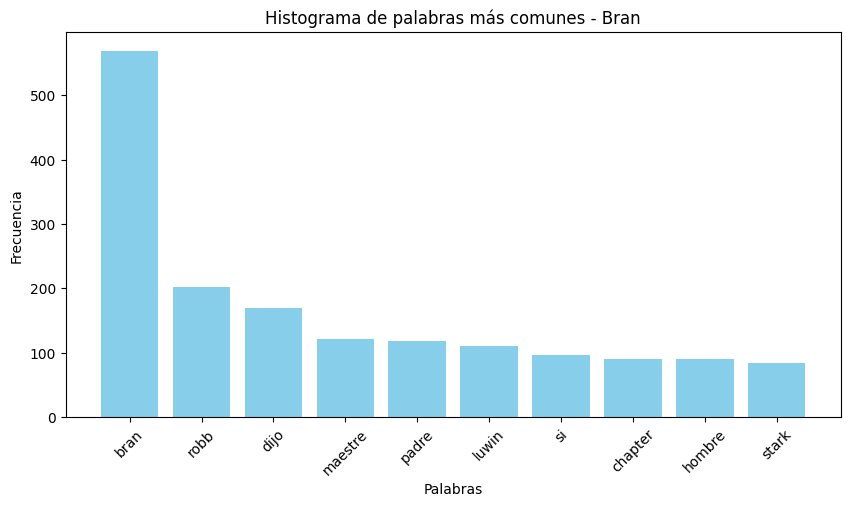

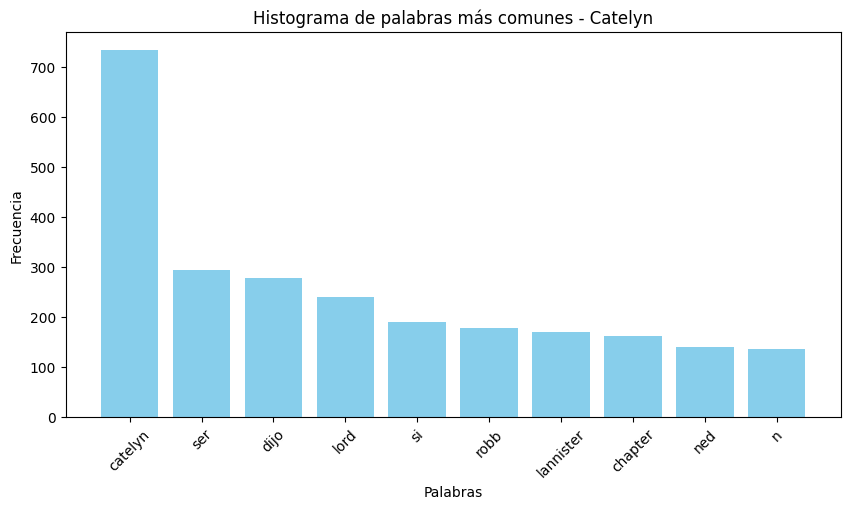

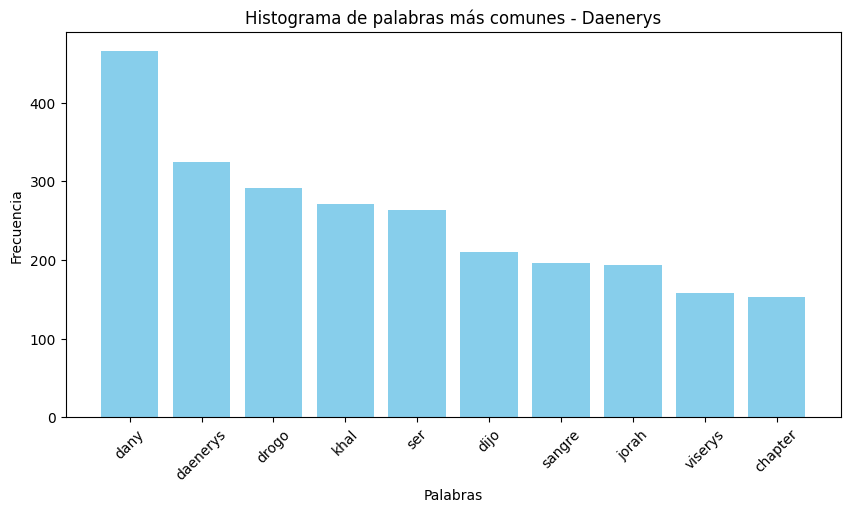

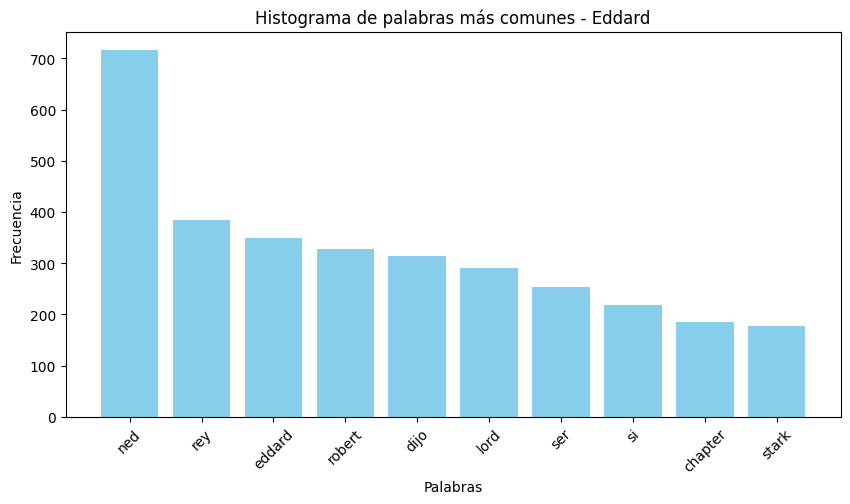

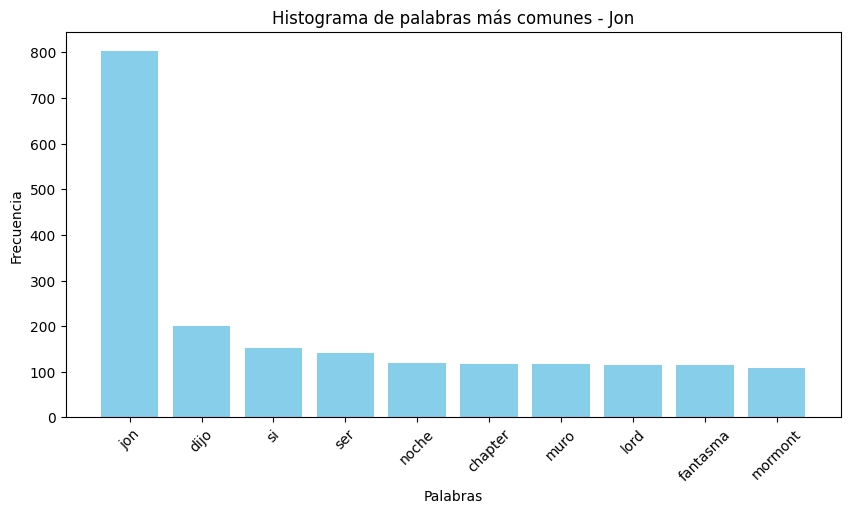

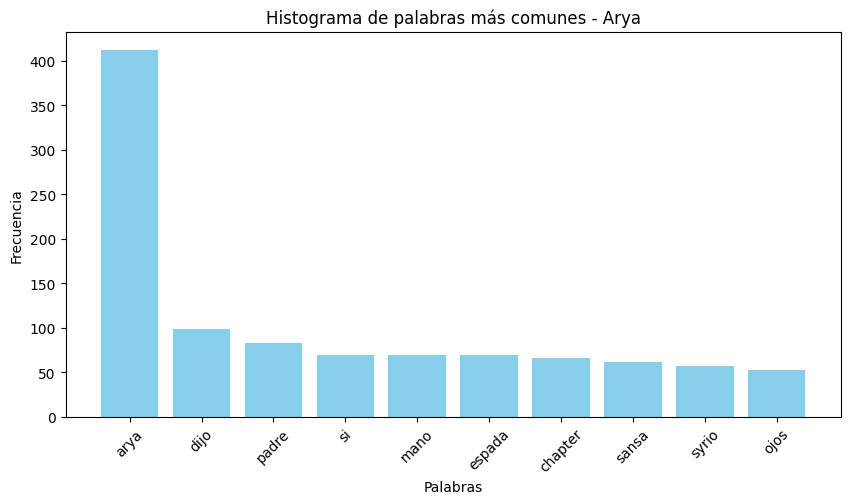

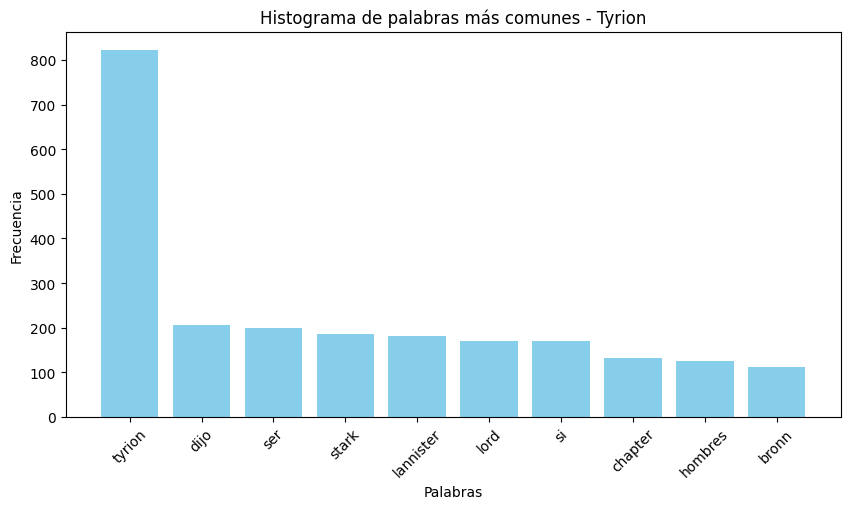

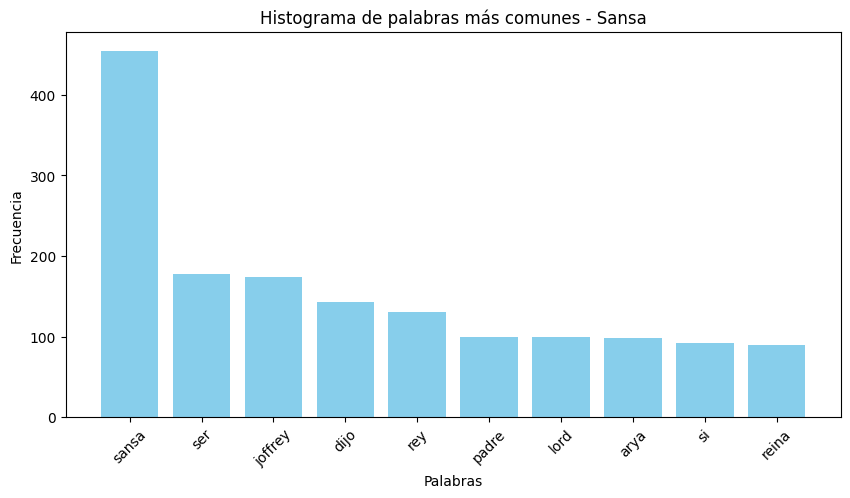

In [30]:
def plot_histogram(word_counts, history):
    words, counts = zip(*word_counts)
    plt.figure(figsize=(10, 5))
    plt.bar(words, counts, color='skyblue')
    plt.xlabel("Palabras")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de palabras más comunes - {history.capitalize()}")
    plt.xticks(rotation=45)
    plt.show()

for history, word_counts in rankings.items():
    plot_histogram(word_counts, history)

Como vemos, en todos los POV la palabra más común es el nombre del POV, pues al estar escritos en tercera persona, muchas veces se escriben cosas como: pensó Bran, dijo Tyrion...

Además, alguien que sepa del mundo de Juego de Tronos entenderá perfectamente estas distribuciones, pues claramente tienen sentido dentro de cada personaje. Por ejemplo, en el caso de Daenerys, la palabra sangre vendrá porque el lema de su casa es "Fuego y Sangre".

En el caso de Jon, el muro es donde él pasa la mayor parte de la novela, Fantasta es el nombre de su lobo huargo...


Ahora, hagamos el mismo análisis pero con las palabras menos frecuentes de cada POV:

In [31]:
oov_per_label = {}

for label in df['pov'].unique():
    texts = df[df['pov'] == label]['documents']

    words = [word for text in texts for word in str(text).lower().split()]
    freq_dist = Counter(words)

    oov_words = [word for word, freq in freq_dist.items() if freq == 1]

    oov_per_label[label] = oov_words

    print(f"\label: {label}")
    print("Número de oov:", len(oov_words))
    print("Algunas palabras oov:", oov_words[:20])


\label: nan
Número de oov: 0
Algunas palabras oov: []
\label: BRAN
Número de oov: 4392
Algunas palabras oov: ['decapitación,', 'justicia,', 'salvajes,', 'coraje', 'acusado', 'amanecido', 'despejado,', 'vivificante', 'señalaba', 'aurora', 'total,', 'nervioso', 'consideraban', 'acompañar', 'presenciar', 'noveno', 'séptimo', 'sacado', 'colinas.', 'servicio']
\label: CATELYN
Número de oov: 6371
Algunas palabras oov: ['educación', 'stark:', '"se', 'invierno".', 'venas,', 'alegre', 'despejado,', 'proyectaban', 'cristalinos,', 'cantaban', 'nidos', 'escondidos', 'aroma', 'impregnaba', 'primitivo,', 'acres', 'tocado', 'putrefacción.', 'secuoyas.', 'recios']
\label: DAENERYS
Número de oov: 6445
Algunas palabras oov: ['examinara.', '—mira', 'tócalo.', 'acaricia', 'tela.', 'tocó.', 'delicado.', 'asustó', 'humor—.', 'resaltará', 'dispondrás', 'muchas.', '—preguntó—.', 'viviendo', 'comiendo', 'mesa', 'mimados', 'criados.', 'aquéllos', 'desinteresados']
\label: EDDARD
Número de oov: 6988
Algunas pala

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_48927/2946357761.py:13: SyntaxWarning: invalid escape sequence '\l'
  print(f"\label: {label}")


Son palabras muy normal, no tienen nada de especial en general. Vemos que EDDARD es el personaje con más palabras poco frecuentes, pues es el personaje con más capítulos, y por probabilidad, él será el que más palabras use.

In [32]:
oov = sum(1 for word, freq in freq_dist.items() if freq == 1)
print("% de palabras únicas en todo el vocabulario ratio:", oov / len(freq_dist))

% de palabras únicas en todo el vocabulario ratio: 0.647599429567422


El ratio de palabras única en todo el corpus es de 0.65%.

Continuemos con los n-gramas. En este mundo en particular los n-gramas son importantes, tales como "Mano del Rey", "Trono de Hierro"... Veamos si los podemos detectar bien:

In [33]:
bigrams = []
trigrams = []

for text in df['documents']:
    tokens = text.lower().split()
    bigrams.extend(list(ngrams(tokens, 2)))
    trigrams.extend(list(ngrams(tokens, 3)))

print(Counter(bigrams).most_common(50))
print(Counter(trigrams).most_common(50))

[(('de', 'la'), 2210), (('en', 'el'), 1169), (('de', 'los'), 1128), (('en', 'la'), 1048), (('a', 'la'), 956), (('a', 'su'), 719), (('de', 'su'), 681), (('que', 'se'), 642), (('lo', 'que'), 642), (('a', 'los'), 613), (('de', 'las'), 546), (('de', 'que'), 544), (('y', 'se'), 513), (('y', 'la'), 466), (('y', 'el'), 459), (('que', 'no'), 454), (('con', 'la'), 421), (('de', 'un'), 399), (('con', 'el'), 394), (('y', 'los'), 368), (('que', 'el'), 367), (('que', 'le'), 363), (('que', 'la'), 342), (('por', 'el'), 336), (('chapter', 'order:'), 328), (('main', 'event:'), 328), (('text:', 'chapter:'), 328), (('que', 'los'), 324), (('con', 'una'), 316), (('por', 'la'), 299), (('en', 'las'), 292), (('la', 'mano'), 273), (('los', 'ojos'), 268), (('la', 'guardia'), 267), (('y', 'le'), 264), (('junto', 'a'), 264), (('no', 'se'), 262), (('que', 'lo'), 261), (('a', 'un'), 260), (('con', 'un'), 258), (('en', 'los'), 257), (('se', 'había'), 256), (('pero', 'no'), 256), (('en', 'su'), 249), (('dice', 'que')

Sin eliminar las StopWords, vemos que muchos de los top n-gramas no aportan nada, pero sí que se ve alguna cosa familiar como "desembarco del rey", "el maestre luwin", "la mano"...

Veamos qué pasa si quitamos las StopWords:

In [34]:
bigrams = []
trigrams = []

for text in df['documents_sin_stop']:
    tokens = text.lower().split()
    bigrams.extend(list(ngrams(tokens, 2)))
    trigrams.extend(list(ngrams(tokens, 3)))

print(Counter(bigrams).most_common(50))
print(Counter(trigrams).most_common(50))

[(('chapter', 'order'), 328), (('main', 'event'), 328), (('text', 'chapter'), 328), (('ser', 'jorah'), 221), (('khal', 'drogo'), 174), (('desembarco', 'rey'), 166), (('ser', 'rodrik'), 166), (('guardia', 'noche'), 165), (('maestre', 'luwin'), 164), (('lord', 'tywin'), 163), (('lord', 'eddard'), 150), (('tyrion', 'lannister'), 146), (('chapter', 'eddard'), 124), (('pov', 'eddard'), 124), (('locations', 'n'), 115), (('n', 'keywords'), 115), (('characters', 'n'), 114), (('n', 'houses'), 114), (('houses', 'n'), 114), (('n', 'locations'), 114), (('keywords', 'n'), 114), (('n', 'main'), 114), (('event', 'n'), 114), (('n', 'text'), 114), (('eddard', 'stark'), 112), (('nido', 'águilas'), 109), (('chapter', 'catelyn'), 108), (('pov', 'catelyn'), 108), (('chapter', 'daenerys'), 102), (('pov', 'daenerys'), 102), (('dijo', 'ned'), 99), (('jon', 'arryn'), 97), (('septa', 'mordane'), 95), (('aquel', 'momento'), 95), (('ser', 'barristan'), 94), (('lord', 'comandante'), 93), (('siete', 'reinos'), 90),

Ahora hay muchos "Ser Nombre", o "Nombre, Apellido", mucho mejor.

Ahora, veamos posibles correlaciones entre personajes

In [35]:
pov_unicos = df['pov'].dropna().unique()
pov_mapping = {personaje: i for i, personaje in enumerate(pov_unicos)}

df['pov_number'] = df['pov'].map(pov_mapping)

print("Diccionario de mapeo de POV:")
print(pov_mapping)

Diccionario de mapeo de POV:
{'BRAN': 0, 'CATELYN': 1, 'DAENERYS': 2, 'EDDARD': 3, 'JON': 4, 'ARYA': 5, 'TYRION': 6, 'SANSA': 7}


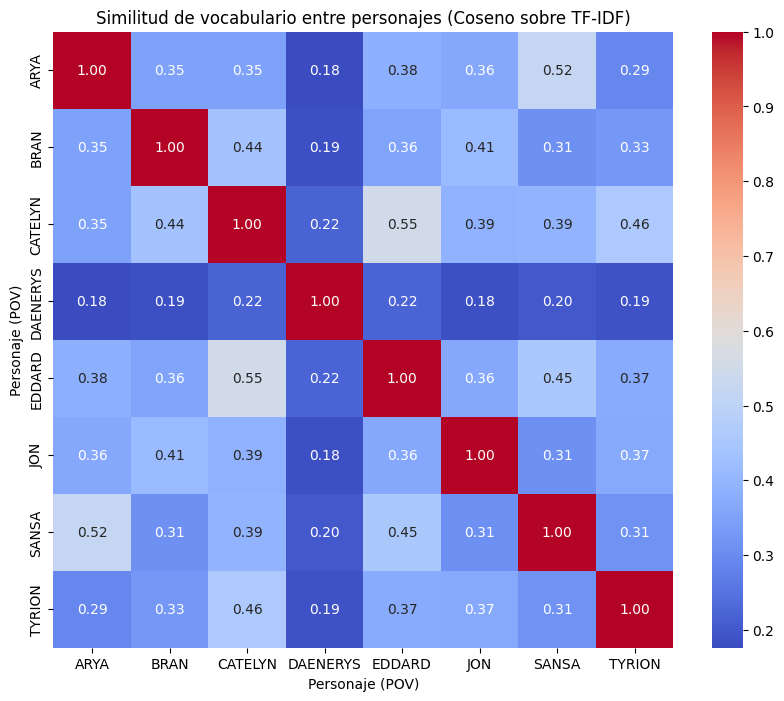

In [36]:


pov_texts = df.dropna(subset=['pov']).groupby('pov')['documents_sin_stop'].apply(lambda x: ' '.join(x)).reset_index()

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(pov_texts['documents_sin_stop'])

similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(similarity_matrix, index=pov_texts['pov'], columns=pov_texts['pov'])

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Similitud de vocabulario entre personajes (Coseno sobre TF-IDF)')
plt.ylabel('Personaje (POV)')
plt.xlabel('Personaje (POV)')
plt.show()

Vemos que el personaje que menos correlación tiene con el resto (es decir, tiene un azul más oscuro), es Daenerys. Esto se explica porque Daeneys está "a su bola" con los Dothrakys, mientras en Poniente el resto de casa interactuan entre ellas.

También vemos que Catelyn y Eddard tienen la mayor correlación, cosa que se explica sabiendo que son marido y mujer.

Snsa y Arya también tienen un alto valor (0.52) ya que son hermanas.

Tyrion tiene con Catelyn su mayor correlación, pues este es apresado por Catelyn, pasando mucho tiempo juntos.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


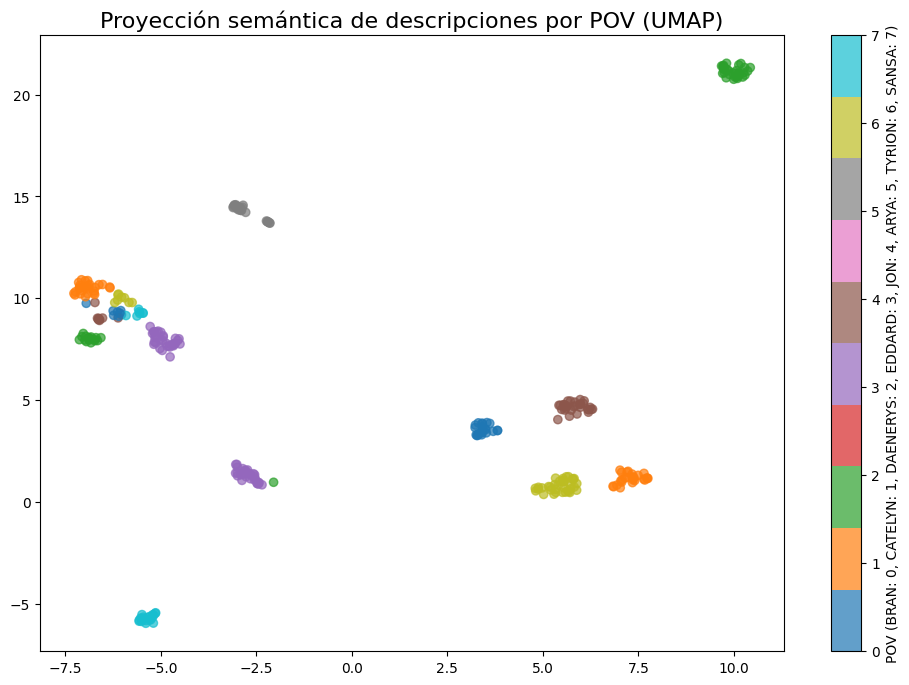

In [37]:
# Filtramos los datos para usar solo aquellos que tienen un POV asignado
df_plot = df.dropna(subset=['pov_number']).copy()

# Usamos un modelo multilingüe de SentenceTransformers
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

# Obtener embeddings del corpus filtrado
embeddings = model.encode(df_plot['documents'].tolist(), show_progress_bar=True)

# Reducir dimensionalidad con UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
reduced = reducer.fit_transform(embeddings)

# Generamos el texto de la leyenda basado en nuestro diccionario pov_mapping
leyenda_pov = ", ".join([f"{k}: {v}" for k, v in pov_mapping.items()])

plt.figure(figsize=(12,8))
scatter = plt.scatter(
    reduced[:,0], reduced[:,1],
    c=df_plot['pov_number'],
    cmap='tab10',  # 'tab10' es mejor para variables categóricas que 'coolwarm'
    alpha=0.7
)
plt.title("Proyección semántica de descripciones por POV (UMAP)", fontsize=16)
plt.colorbar(scatter, label=f"POV ({leyenda_pov})")
plt.show()

## Topic Modeling

Una prueba interesante que podríamos hacer es el realizar un Topic Modeling en ambas colecciones (la del libro y la de los resúmenes) y ver si los topics coinciden con los POVs en ambas colecciones.

Vamos a conseguir tres modelos de LDA: uno para la colección de los libros, otro para la colección de los resúmenes y otro para la colección total. Como no sabemos que K elegir, vamos a hacerlo de forma automática, recorriendo todas las K en un rango de 1 a 30, y usando el Coherence Score como métrica para ver qué K es la idonea.

Guardaremos los modelos en memoria para luego hacer pruebas con ellos.

In [38]:
documents_libro = [str(text).split() for text in df_libro['documents']]

dictionary_libro = corpora.Dictionary(documents_libro)

corpus_libro = [dictionary_libro.doc2bow(doc) for doc in documents_libro]

documents_resumenes = [str(text).split() for text in df_resumenes['documents']]

dictionary_resumenes = corpora.Dictionary(documents_resumenes)

corpus_resumenes = [dictionary_resumenes.doc2bow(doc) for doc in documents_resumenes]

documents_total = [str(text).split() for text in df['documents']]

dictionary_total = corpora.Dictionary(documents_total)

corpus_total = [dictionary_total.doc2bow(doc) for doc in documents_total]


## Preprocesado y limpieza del corpus para Topic Modeling

Antes de aplicar los modelos de *Topic Modeling* mediante LDA (*Latent Dirichlet Allocation*), se realizó una fase de preprocesado específica orientada a mejorar la calidad semántica de los tópicos generados. El objetivo principal de esta etapa fue reducir el ruido lingüístico y estructural del corpus, preservando al mismo tiempo la información narrativa relevante.

### Eliminación de metadatos estructurales

Los fragmentos del corpus original incluían información auxiliar añadida durante la construcción de los *chunks*, como:

- títulos de capítulo,
- POV (*Point of View*),
- listas de personajes,
- localizaciones,
- palabras clave,
- eventos principales.

Aunque estos metadatos pueden ser útiles para tareas de recuperación o análisis descriptivo, introducen un sesgo artificial en LDA, ya que generan términos extremadamente frecuentes que no representan realmente el contenido temático de los textos.

Por este motivo, se eliminaron automáticamente todas las cabeceras y etiquetas estructurales mediante expresiones de limpieza específicas.

---

### Normalización del texto

El texto se transformó a minúsculas y se eliminaron caracteres no lingüísticos, manteniendo únicamente:

- letras,
- espacios,
- caracteres propios del español (`á`, `é`, `í`, `ó`, `ú`, `ü`, `ñ`).

Esta normalización reduce la fragmentación artificial del vocabulario y evita que diferentes variantes ortográficas de una misma palabra sean tratadas como términos distintos.

---

### Eliminación de *stopwords*

Se utilizaron las *stopwords* estándar de NLTK para español junto con varias listas adicionales diseñadas específicamente para este corpus narrativo.

#### Stopwords estructurales

Se eliminaron términos derivados de las etiquetas internas del dataset, como:

- `chapter`,
- `pov`,
- `characters`,
- `houses`,
- `locations`,
- `keywords`,
- `main event`.

Estos términos no aportan contenido semántico útil para la identificación de tópicos.

#### Stopwords narrativas

Debido a la naturaleza literaria del corpus, también se eliminaron expresiones narrativas extremadamente frecuentes que aparecían de forma transversal en prácticamente todos los capítulos, por ejemplo:

- verbos de diálogo (`dijo`, `preguntó`, `respondió`),
- verbos narrativos generales (`miró`, `pensó`, `parecía`),
- palabras excesivamente genéricas (`mano`, `ojos`, `momento`, `vida`).

Aunque estas palabras tienen significado lingüístico, su alta frecuencia y baja especificidad temática provocaban que varios tópicos se construyesen alrededor de patrones narrativos comunes en lugar de conceptos relevantes del universo de la obra.

El objetivo de esta eliminación no fue simplificar el lenguaje, sino aumentar la capacidad discriminativa del modelo.

---

### Conservación de entidades narrativas relevantes

A diferencia de otros enfoques clásicos de NLP, no se eliminaron nombres de personajes, lugares o casas nobiliarias, ya que en un corpus literario estas entidades constituyen parte fundamental de la estructura temática.

Por ejemplo, términos como:

- `tyrion`,
- `eddard`,
- `daenerys`,
- `lannister`,
- `guardia noche`

aportan una fuerte señal semántica y permiten que los tópicos reflejen facciones, tramas, localizaciones y relaciones narrativas reales.

---

### Normalización de aliases y variantes

También se aplicó una normalización manual de entidades para unificar distintas referencias a un mismo personaje. Por ejemplo:

- `ned` → `eddard`
- `dany` → `daenerys`

Esto evita dispersar frecuencia entre aliases diferentes y mejora la coherencia de los tópicos generados.

---

### Filtrado final de tokens

Finalmente, se eliminaron:

- tokens vacíos,
- palabras de longitud menor o igual a 2 caracteres,
- términos incluidos en las listas de stopwords.

El resultado final fue un corpus considerablemente más limpio y semánticamente más consistente, optimizado específicamente para técnicas de *Topic Modeling* narrativo mediante LDA.

In [39]:
# =========================
# LIMPIEZA REFINADA PARA LDA
# =========================
nltk.download("stopwords")

# =========================
# STOPWORDS
# =========================

stopwords_es = set(stopwords.words("spanish"))

stopwords_estructurales = {
    # Ruido estructural
    "chapter", "order", "pov", "characters", "houses",
    "locations", "keywords", "main", "event",
    "text", "na", "n",
}

stopwords_narrativas = {
    # Honoríficos y títulos
    "ser", "lord", "señor",

    # Narración extremadamente frecuente
    "dijo", "preguntó", "replicó", "respondió",
    "murmuró", "exclamó", "gritó", "susurró",
    "contestó", "añadió", "comentó",

    # Verbos narrativos frecuentes
    "miró", "vio", "parecía", "pensó",
    "sabía", "podía", "podría", "puede",
    "debía", "debe", "quería", "quiere",

    # Palabras demasiado generales
    "hombre", "hombres", "padre",
    "mano", "manos", "ojos", "voz",
    "lado", "momento", "años",
    "día", "vida", "vez", "tiempo",

    # Conectores todavía frecuentes
    "así", "cómo", "allí", "aquí",
    "después", "siempre", "bien",

    # Números escritos frecuentes
    "dos", "tres",
}

stopwords_totales = (
    stopwords_es
    | stopwords_estructurales
    | stopwords_narrativas
)

# =========================
# NORMALIZACIÓN DE ENTIDADES
# =========================

reemplazos_entidades = {
    "ned": "eddard",
    "dany": "daenerys",
}

# =========================
# LIMPIEZA DE METADATOS
# =========================

def quitar_metadatos_libro(texto):
    """
    Elimina cabeceras artificiales añadidas a los chunks del libro.
    """
    texto = str(texto)

    if "Text:" in texto:
        texto = texto.split("Text:", 1)[1]

    prefijos_metadatos = (
        "Chapter:",
        "Chapter order:",
        "POV:",
        "Characters:",
        "Houses:",
        "Locations:",
        "Keywords:",
        "Main event:",
    )

    lineas_limpias = []

    for linea in texto.splitlines():
        linea = linea.strip()

        if not linea:
            continue

        if linea.startswith(prefijos_metadatos):
            continue

        lineas_limpias.append(linea)

    return " ".join(lineas_limpias)

# =========================
# TOKENIZACIÓN FINAL
# =========================

def limpiar_y_tokenizar(texto):
    """
    Preprocesado optimizado para LDA narrativo.
    """

    texto = str(texto).lower()

    # Mantener caracteres españoles
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)

    tokens = texto.split()

    # Normalización de aliases
    tokens = [
        reemplazos_entidades.get(token, token)
        for token in tokens
    ]

    # Filtrado
    tokens_limpios = [
        token for token in tokens
        if token not in stopwords_totales
        and len(token) > 2
    ]

    return tokens_limpios




[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [40]:
# =========================
# APLICACIÓN AL CORPUS
# =========================

df_libro = df_libro.copy()
df_resumenes = df_resumenes.copy()

# Libro
df_libro["documents_clean"] = (
    df_libro["documents"]
    .apply(quitar_metadatos_libro)
)

df_libro["tokens_clean"] = (
    df_libro["documents_clean"]
    .apply(limpiar_y_tokenizar)
)

# Resúmenes
df_resumenes["documents_clean"] = (
    df_resumenes["documents"]
    .astype(str)
)

df_resumenes["tokens_clean"] = (
    df_resumenes["documents_clean"]
    .apply(limpiar_y_tokenizar)
)

# =========================
# LISTAS FINALES
# =========================

documents_libro_clean = df_libro["tokens_clean"].tolist()
documents_resumenes_clean = df_resumenes["tokens_clean"].tolist()

documents_total_clean = (
    documents_libro_clean
    + documents_resumenes_clean
)


In [41]:
# =========================
# RECONSTRUCCIÓN GENSIM
# =========================
dictionary_libro_clean = corpora.Dictionary(documents_libro_clean)
dictionary_libro_clean.filter_extremes(
    no_below=3,
    no_above=0.60
)

corpus_libro_clean = [
    dictionary_libro_clean.doc2bow(doc)
    for doc in documents_libro_clean
]

dictionary_resumenes_clean = corpora.Dictionary(documents_resumenes_clean)
dictionary_resumenes_clean.filter_extremes(
    no_below=3,
    no_above=0.60
)

corpus_resumenes_clean = [
    dictionary_resumenes_clean.doc2bow(doc)
    for doc in documents_resumenes_clean
]

dictionary_total_clean = corpora.Dictionary(documents_total_clean)
dictionary_total_clean.filter_extremes(
    no_below=3,
    no_above=0.60
)

corpus_total_clean = [
    dictionary_total_clean.doc2bow(doc)
    for doc in documents_total_clean
]

# =========================
# RESUMEN
# =========================

print("Libro:")
print("Docs:", len(documents_libro_clean))
print("Vocabulario:", len(dictionary_libro_clean))

print("\nResúmenes:")
print("Docs:", len(documents_resumenes_clean))
print("Vocabulario:", len(dictionary_resumenes_clean))

print("\nTotal:")
print("Docs:", len(documents_total_clean))
print("Vocabulario:", len(dictionary_total_clean))

print("\nEjemplo tokens libro:")
print(documents_libro_clean[0][:80])

print("\nEjemplo tokens resumen:")
print(documents_resumenes_clean[0][:80])

Libro:
Docs: 328
Vocabulario: 7037

Resúmenes:
Docs: 320
Vocabulario: 1265

Total:
Docs: 648
Vocabulario: 7609

Ejemplo tokens libro:
['bran', 'amanecido', 'fresco', 'despejado', 'frío', 'vivificante', 'señalaba', 'final', 'verano', 'pusieron', 'marcha', 'aurora', 'ver', 'decapitación', 'veinte', 'total', 'bran', 'cabalgaba', 'nervioso', 'emocionado', 'primera', 'consideraban', 'suficientemente', 'mayor', 'acompañar', 'hermanos', 'presenciar', 'justicia', 'rey', 'corría', 'noveno', 'año', 'verano', 'séptimo', 'bran', 'sacado', 'pequeño', 'fortín', 'colinas', 'robb', 'creía', 'trataba', 'salvaje', 'puesto', 'espada', 'servicio', 'mance', 'rayder', 'rey', 'allá', 'muro', 'bran', 'ponía', 'carne', 'gallina', 'sólo', 'pensarlo', 'recordaba', 'historias', 'vieja', 'tata', 'contado', 'junto', 'chimenea', 'salvajes', 'crueles', 'decía', 'esclavistas', 'asesinos', 'ladrones', 'apareaban', 'gigantes', 'espíritus', 'malignos', 'llevaban', 'niños', 'cunas', 'mitad', 'noche', 'bebían']

Ejemplo to

#### Código para no tener que repetir la busqueda de K óptima

In [52]:
lda_model_libro = LdaModel(corpus=corpus_libro_clean, id2word=dictionary_libro_clean, num_topics=7, random_state=42, passes=15, chunksize=200, alpha='auto', per_word_topics=True)

lda_model_resumenes = LdaModel(corpus=corpus_resumenes_clean, id2word=dictionary_resumenes_clean, num_topics=4, random_state=42, passes=15, chunksize=200, alpha='auto', per_word_topics=True)

lda_model_total = LdaModel(corpus=corpus_total_clean, id2word=dictionary_total_clean, num_topics=10, random_state=42, passes=15, chunksize=200, alpha='auto', per_word_topics=True)

#### Función para buscar K optima en cada colección tras el preprocesamiento del texto.

In [60]:
def evaluate_graph(dictionary, corpus, texts, limit, start=2):

    c_scores = []
    models = []

    for k in range(start, limit + 1):

        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=42,
            passes=15,
            chunksize=200,
            alpha='auto',
            per_word_topics=True
        )

        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )

        coherence = coherence_model.get_coherence()

        c_scores.append(coherence)
        models.append(model)

        print(f"K={k} -> Coherencia: {coherence:.4f}")

    return models, c_scores

#### Búsqueda de K optima para la colección del libro

K=2 -> Coherencia: 0.2961
K=3 -> Coherencia: 0.3697
K=4 -> Coherencia: 0.3990
K=5 -> Coherencia: 0.5023
K=6 -> Coherencia: 0.5096
K=7 -> Coherencia: 0.5127
K=8 -> Coherencia: 0.4623
K=9 -> Coherencia: 0.4809
K=10 -> Coherencia: 0.4978
K=11 -> Coherencia: 0.5008
K=12 -> Coherencia: 0.4901
K=13 -> Coherencia: 0.4715
K=14 -> Coherencia: 0.4832
K=15 -> Coherencia: 0.5013
K=16 -> Coherencia: 0.4373
K=17 -> Coherencia: 0.4871
K=18 -> Coherencia: 0.4740
K=19 -> Coherencia: 0.4626
K=20 -> Coherencia: 0.4532
K=21 -> Coherencia: 0.4391
K=22 -> Coherencia: 0.4771
K=23 -> Coherencia: 0.4740
K=24 -> Coherencia: 0.4534
K=25 -> Coherencia: 0.4633
K=26 -> Coherencia: 0.4173
K=27 -> Coherencia: 0.4667
K=28 -> Coherencia: 0.4597
K=29 -> Coherencia: 0.4303
K=30 -> Coherencia: 0.4290


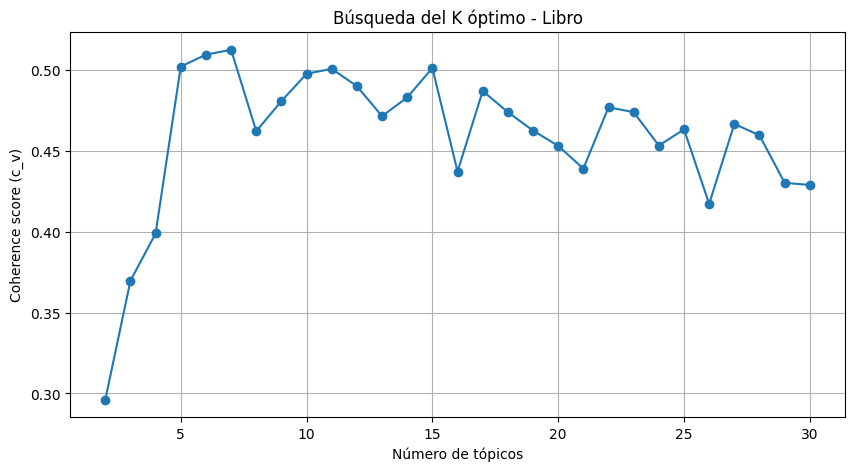

Mejor número de temas: 7
Mejor coherencia: 0.5127


In [61]:
limit_k = 30
start_k = 2

models_libro, scores_libro = evaluate_graph(
    dictionary_libro_clean,
    corpus_libro_clean,
    documents_libro_clean,
    limit_k,
    start=start_k
)

k_values = list(range(start_k, limit_k + 1))

plt.figure(figsize=(10, 5))
plt.plot(k_values, scores_libro, marker='o')

plt.xlabel("Número de tópicos")
plt.ylabel("Coherence score (c_v)")
plt.title("Búsqueda del K óptimo - Libro")

plt.grid(True)
plt.show()

best_index_libro = np.argmax(scores_libro)

best_k_libro = k_values[best_index_libro]

lda_model_libro = models_libro[best_index_libro]

print(f"Mejor número de temas: {best_k_libro}")
print(f"Mejor coherencia: {scores_libro[best_index_libro]:.4f}")

#### Búsqueda de K optima para la colección de los resumenes

K=2 -> Coherencia: 0.3541
K=3 -> Coherencia: 0.4662
K=4 -> Coherencia: 0.5188
K=5 -> Coherencia: 0.4301
K=6 -> Coherencia: 0.3912
K=7 -> Coherencia: 0.4067
K=8 -> Coherencia: 0.4350
K=9 -> Coherencia: 0.4095
K=10 -> Coherencia: 0.4123
K=11 -> Coherencia: 0.4059
K=12 -> Coherencia: 0.3827
K=13 -> Coherencia: 0.4103
K=14 -> Coherencia: 0.3707
K=15 -> Coherencia: 0.3935
K=16 -> Coherencia: 0.3990
K=17 -> Coherencia: 0.3781
K=18 -> Coherencia: 0.3751
K=19 -> Coherencia: 0.3991
K=20 -> Coherencia: 0.3757
K=21 -> Coherencia: 0.3700
K=22 -> Coherencia: 0.3535
K=23 -> Coherencia: 0.3701
K=24 -> Coherencia: 0.3886
K=25 -> Coherencia: 0.3733
K=26 -> Coherencia: 0.3820
K=27 -> Coherencia: 0.3545
K=28 -> Coherencia: 0.3691
K=29 -> Coherencia: 0.3569
K=30 -> Coherencia: 0.3573


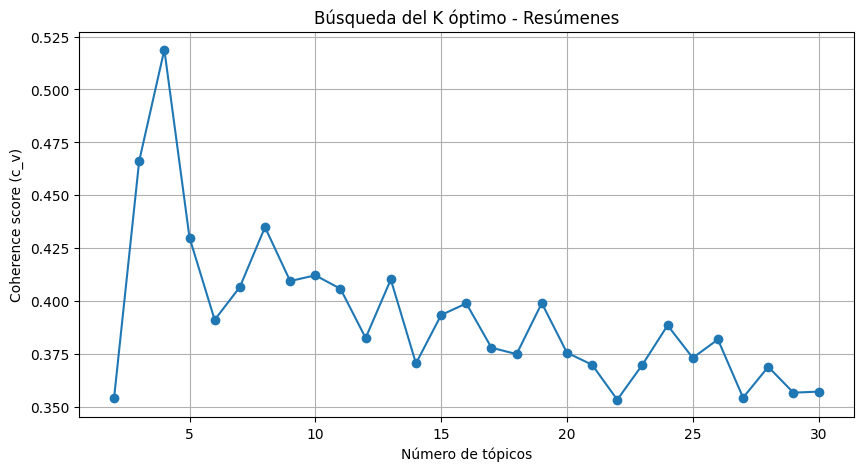

Mejor número de temas: 4
Mejor coherencia: 0.5188


In [62]:
models_resumenes, scores_resumenes = evaluate_graph(
    dictionary_resumenes_clean,
    corpus_resumenes_clean,
    documents_resumenes_clean,
    limit_k,
    start=start_k
)

k_values = list(range(start_k, limit_k + 1))

plt.figure(figsize=(10, 5))
plt.plot(k_values, scores_resumenes, marker='o')

plt.xlabel("Número de tópicos")
plt.ylabel("Coherence score (c_v)")
plt.title("Búsqueda del K óptimo - Resúmenes")

plt.grid(True)
plt.show()

best_index_resumenes = np.argmax(scores_resumenes)

best_k_resumenes = k_values[best_index_resumenes]

lda_model_resumenes = models_resumenes[best_index_resumenes]

print(f"Mejor número de temas: {best_k_resumenes}")
print(f"Mejor coherencia: {scores_resumenes[best_index_resumenes]:.4f}")

#### Búsqueda de K optima para la colección total

K=2 -> Coherencia: 0.3065
K=3 -> Coherencia: 0.4544
K=4 -> Coherencia: 0.4548
K=5 -> Coherencia: 0.4420
K=6 -> Coherencia: 0.5263
K=7 -> Coherencia: 0.5212
K=8 -> Coherencia: 0.5145
K=9 -> Coherencia: 0.5087
K=10 -> Coherencia: 0.5353
K=11 -> Coherencia: 0.4970
K=12 -> Coherencia: 0.5121
K=13 -> Coherencia: 0.4953
K=14 -> Coherencia: 0.4699
K=15 -> Coherencia: 0.4874
K=16 -> Coherencia: 0.4651
K=17 -> Coherencia: 0.4887
K=18 -> Coherencia: 0.4898
K=19 -> Coherencia: 0.4697
K=20 -> Coherencia: 0.4889
K=21 -> Coherencia: 0.4503
K=22 -> Coherencia: 0.4706
K=23 -> Coherencia: 0.4345
K=24 -> Coherencia: 0.4749
K=25 -> Coherencia: 0.4656
K=26 -> Coherencia: 0.4619
K=27 -> Coherencia: 0.4516
K=28 -> Coherencia: 0.4205
K=29 -> Coherencia: 0.4147
K=30 -> Coherencia: 0.4219


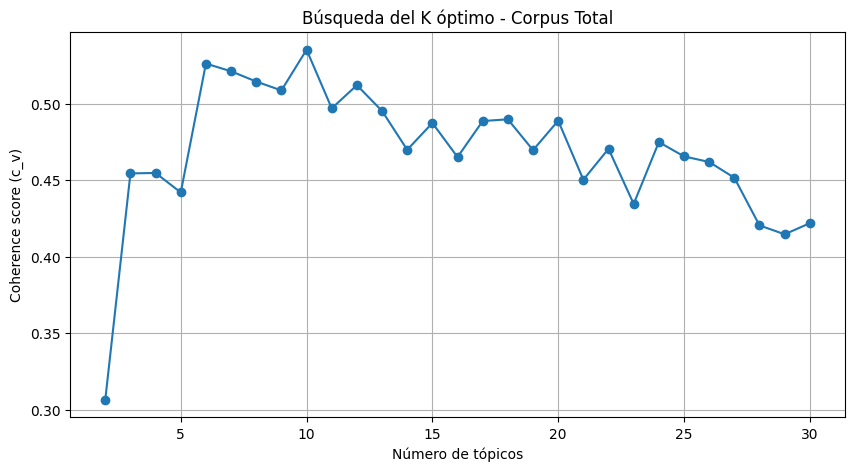

Mejor número de temas: 10
Mejor coherencia: 0.5353


In [63]:
models_total, scores_total = evaluate_graph(
    dictionary_total_clean,
    corpus_total_clean,
    documents_total_clean,
    limit_k,
    start=start_k
)

k_values = list(range(start_k, limit_k + 1))

plt.figure(figsize=(10, 5))
plt.plot(k_values, scores_total, marker='o')

plt.xlabel("Número de tópicos")
plt.ylabel("Coherence score (c_v)")
plt.title("Búsqueda del K óptimo - Corpus Total")

plt.grid(True)
plt.show()

best_index_total = np.argmax(scores_total)

best_k_total = k_values[best_index_total]

lda_model_total = models_total[best_index_total]

print(f"Mejor número de temas: {best_k_total}")
print(f"Mejor coherencia: {scores_total[best_index_total]:.4f}")

Vamos a analizar los resultados:

- En la colección del libro, la K optima es de 7. Consideramos que es un buen valor, pues hay 8 POVS en el libro. El valor de la coherencia, de 0.51, puede considerarse como suficiente

- En la colección de los resumenes, la K optima es de 4, algo baja. No obstante, la coherencia no es mala (0.5188). 

- En cambio, en la colección total, la K optima vuelve a subir hasta los 10, con una coherencia de 0.5353, la máxima de las tres.

Una vez tenemos los modelos, vamos a empezar por analizar los topics de forma manual viendo las palabras clave e cada uno, para ver si vemos algo interesante.

In [53]:
for idx, topic in lda_model_libro.print_topics(num_words=15):
    print("\n" + "=" * 80)
    print(f"TÓPICO {idx}")
    print("=" * 80)
    print(topic)


TÓPICO 0
0.014*"eddard" + 0.010*"tyrion" + 0.009*"catelyn" + 0.008*"lannister" + 0.006*"hijo" + 0.006*"robert" + 0.005*"stark" + 0.004*"robb" + 0.003*"tywin" + 0.003*"gran" + 0.003*"hijos" + 0.003*"señores" + 0.003*"jaime" + 0.003*"casa" + 0.003*"dioses"

TÓPICO 1
0.021*"jon" + 0.012*"bran" + 0.006*"maestre" + 0.005*"robb" + 0.005*"noche" + 0.005*"espada" + 0.004*"muro" + 0.004*"mormont" + 0.004*"luwin" + 0.004*"dioses" + 0.003*"guardia" + 0.003*"lobo" + 0.003*"nieve" + 0.003*"stark" + 0.003*"fantasma"

TÓPICO 2
0.017*"arya" + 0.015*"syrio" + 0.014*"espada" + 0.007*"madera" + 0.006*"izquierda" + 0.006*"forel" + 0.006*"lanzó" + 0.005*"eddard" + 0.005*"cayó" + 0.005*"espadas" + 0.005*"guardia" + 0.005*"acero" + 0.005*"puerta" + 0.005*"gato" + 0.005*"capas"

TÓPICO 3
0.059*"arya" + 0.010*"sansa" + 0.008*"joffrey" + 0.007*"aguja" + 0.005*"septa" + 0.005*"espada" + 0.005*"chico" + 0.005*"loba" + 0.005*"nymeria" + 0.005*"príncipe" + 0.004*"niña" + 0.004*"capas" + 0.004*"multitud" + 0.004*"v

Entre los 7 topics, parece ver algo más o menos claro:

- Topic 0: Parece que es el Topic de Ned y todo lo que le rodea.
- Topic 1: Parece el Topic de Jon Nieve y todo lo que tien que ver con el muro (Jon, Muro, Mormont...)
- Topic 2: Parece la trama de Arya, cuando le dan la espada, cuando entrena con Syrio...
- Topic 3: Parece la trama de Arya con su familia, cuando se enfrenta al principe Joffrey...
- Topic 4: Parece todo el Topic de Daenerys, con Khal, los dragones...
- Topic 5: Parece todo lo que tiene que ver con la captura de Tyrion y su viaje al Nido de Águilas
- Topic 6: Paraece todo lo que tien eque ver con los Lannister y Sansa en Desembarco del Rey-

A simple vista, parece que los Topics están muy muy bien separados.

In [54]:
for idx, topic in lda_model_resumenes.print_topics(num_words=15):
    print("\n" + "=" * 80)
    print(f"TÓPICO {idx}")
    print("=" * 80)
    print(topic)


TÓPICO 0
0.038*"eddard" + 0.021*"dice" + 0.019*"sansa" + 0.017*"robert" + 0.016*"bran" + 0.016*"arya" + 0.015*"rey" + 0.015*"joffrey" + 0.010*"maestre" + 0.008*"cersei" + 0.008*"pregunta" + 0.007*"jon" + 0.007*"acerca" + 0.007*"robb" + 0.007*"guardia"

TÓPICO 1
0.056*"daenerys" + 0.033*"drogo" + 0.033*"viserys" + 0.024*"jorah" + 0.016*"khal" + 0.013*"dothraki" + 0.013*"sangre" + 0.011*"dice" + 0.009*"dragón" + 0.008*"hermano" + 0.008*"jinetes" + 0.007*"khalasar" + 0.006*"caballo" + 0.006*"hijo" + 0.006*"pregunta"

TÓPICO 2
0.057*"jon" + 0.018*"mormont" + 0.014*"dice" + 0.014*"noche" + 0.013*"fantasma" + 0.011*"muro" + 0.011*"samwell" + 0.011*"guardia" + 0.009*"aemon" + 0.009*"espada" + 0.009*"sam" + 0.009*"negro" + 0.009*"tyrion" + 0.008*"comandante" + 0.008*"lobo"

TÓPICO 3
0.023*"tyrion" + 0.020*"catelyn" + 0.016*"jon" + 0.015*"stark" + 0.015*"lannister" + 0.015*"rey" + 0.014*"robb" + 0.012*"dice" + 0.010*"eddard" + 0.009*"pregunta" + 0.008*"hijo" + 0.008*"ejército" + 0.007*"hermano

En este caso, tenemos menos topics. Veamos que intenta representar cada uno:

- Topic 0: Parece todo lo que tiene que ver con los Stark en general; desde Eddard y sansa, hasta maestre...
- Topic 1: Todo lo que tiene que ver con los Targaryen y Daenerys.
- Topic 2: Todo lo que tiene que ver con el muro y Jon Nieve, que es una trama a parte de los Stark.
- Topic 3: Todo lo que tiene que ver con los Lannister, la captura de Tyrion y Catelyn...

Nuevamente, aunque con menos Topics, parece captar muy bien las 4 tramas principales del libro y las familias más importantes.

In [55]:
for idx, topic in lda_model_total.print_topics(num_words=15):
    print("\n" + "=" * 80)
    print(f"TÓPICO {idx}")
    print("=" * 80)
    print(topic)


TÓPICO 0
0.015*"tyrion" + 0.006*"espada" + 0.006*"hacia" + 0.006*"cabeza" + 0.006*"tan" + 0.005*"mientras" + 0.005*"dio" + 0.004*"rostro" + 0.004*"hizo" + 0.004*"chico" + 0.004*"stark" + 0.003*"puerta" + 0.003*"ver" + 0.003*"lannister" + 0.003*"caballero"

TÓPICO 1
0.007*"tan" + 0.007*"hermano" + 0.005*"dioses" + 0.005*"mientras" + 0.004*"caballo" + 0.004*"sólo" + 0.004*"hijo" + 0.004*"hijos" + 0.004*"hacia" + 0.003*"eddard" + 0.003*"casa" + 0.003*"siete" + 0.003*"rey" + 0.003*"quiero" + 0.003*"aquel"

TÓPICO 2
0.043*"eddard" + 0.028*"rey" + 0.018*"robert" + 0.013*"lannister" + 0.012*"dice" + 0.010*"tyrion" + 0.010*"stark" + 0.008*"jaime" + 0.008*"cersei" + 0.007*"reina" + 0.007*"tywin" + 0.006*"meñique" + 0.006*"varys" + 0.006*"joffrey" + 0.006*"gran"

TÓPICO 3
0.099*"catelyn" + 0.024*"lysa" + 0.022*"frey" + 0.021*"robb" + 0.019*"aguasdulces" + 0.018*"lady" + 0.016*"rodrik" + 0.015*"hijo" + 0.014*"tully" + 0.014*"señora" + 0.011*"lannister" + 0.011*"brynden" + 0.011*"walder" + 0.010*

Para terminar, veamos qué nos dicen los topics del corpus total.

- Topic 0: No se ve un tema claro, pero si que parece que tien que ver con algo de Tyrion y los lannister.
- Topic 1: Tampoco se ve nada claro.
- Topic 2: Parece ser algo sobre Ned y su trama con los Lannister.
- Topic 3: Parece que tiene que ver con todo lo que hace Catelyn y su familia de aguas dulces.
- Topic 4: Parece que tiene que ver con Arya, su entrenamiento, su estancia en desembarco...
- Topic 5: Todo lo que tiene que ver con Daenerys.
- Topic 6: Todo lo que tiene que ver con Jon Nieve y el muro
- Topic 7: Nada claro, palabras vacias.
- Topic 8: Toda la trama de Bran cuando se queda lisiado en Invernalia
- Topic 9: Nada claro

Nuevamente, algunos topics si que parecen interesantes, pero otros no aportan información. 

Es decir, parece que las colecciones por separado tienen mucho sentido, pero juntas no tanto. Tiene sentido, pues aunque cuenten lo mismo, una lo hace con mucho más detalle que otra.

Para seguir con el análisis, veamos que Topic domina por POV en la coleccion de los libros. A partir de ahora, utilizaremos el TM de cada colección por separado, porque hemos visto que tienen mucho más sentido con el análisis anterior.

In [56]:
# =========================
# TÓPICO DOMINANTE POR CHUNK DEL LIBRO
# =========================

def obtener_topico_dominante(modelo, corpus):
    resultados = []

    for i, bow in enumerate(corpus):
        distribucion = modelo.get_document_topics(bow, minimum_probability=0.0)

        topic_id, topic_prob = max(distribucion, key=lambda x: x[1])

        resultados.append({
            "doc_idx": i,
            "topic_id": topic_id,
            "topic_prob": topic_prob
        })

    return pd.DataFrame(resultados)


df_topics_libro = obtener_topico_dominante(
    lda_model_libro,
    corpus_libro_clean
)

df_libro_topics = df_libro.copy()
df_libro_topics["topic_id"] = df_topics_libro["topic_id"]
df_libro_topics["topic_prob"] = df_topics_libro["topic_prob"]


In [57]:
# =========================
# CONTEO DE TÓPICOS DOMINANTES POR POV
# =========================

tabla_pov_topic_abs = (
    df_libro_topics
    .groupby(["pov", "topic_id"])
    .size()
    .unstack(fill_value=0)
)

display(tabla_pov_topic_abs)

topic_id,0,1,2,3,4,6
pov,,,,,,
ARYA,3,11,3,5,0,0
BRAN,0,30,0,0,0,0
CATELYN,49,5,0,0,0,0
DAENERYS,5,0,0,1,45,0
EDDARD,60,0,2,0,0,0
JON,1,38,0,0,0,0
SANSA,6,2,0,2,0,16
TYRION,36,8,0,0,0,0


In [58]:
# =========================
# PROPORCIÓN DE TÓPICOS DOMINANTES POR POV
# =========================

tabla_pov_topic_pct = tabla_pov_topic_abs.div(
    tabla_pov_topic_abs.sum(axis=1),
    axis=0
)

display(tabla_pov_topic_pct.round(3))

topic_id,0,1,2,3,4,6
pov,,,,,,
ARYA,0.136,0.500,0.136,0.227,0.000,0.000
BRAN,0.000,1.000,0.000,0.000,0.000,0.000
CATELYN,0.907,0.093,0.000,0.000,0.000,0.000
DAENERYS,0.098,0.000,0.000,0.020,0.882,0.000
EDDARD,0.968,0.000,0.032,0.000,0.000,0.000
JON,0.026,0.974,0.000,0.000,0.000,0.000
SANSA,0.231,0.077,0.000,0.077,0.000,0.615
TYRION,0.818,0.182,0.000,0.000,0.000,0.000


In [59]:
# =========================
# TÓPICO DOMINANTE PRINCIPAL POR POV
# =========================

topic_principal_por_pov = (
    tabla_pov_topic_pct
    .idxmax(axis=1)
    .reset_index()
)

topic_principal_por_pov.columns = ["pov", "topic_id_principal"]

topic_principal_por_pov["proporcion"] = topic_principal_por_pov.apply(
    lambda row: tabla_pov_topic_pct.loc[row["pov"], row["topic_id_principal"]],
    axis=1
)

display(topic_principal_por_pov.sort_values("proporcion", ascending=False))

,pov,topic_id_principal,proporcion
1,BRAN,1,1.000000
5,JON,1,0.974359
4,EDDARD,0,0.967742
2,CATELYN,0,0.907407
3,DAENERYS,4,0.882353
7,TYRION,0,0.818182
6,SANSA,6,0.615385
0,ARYA,1,0.500000


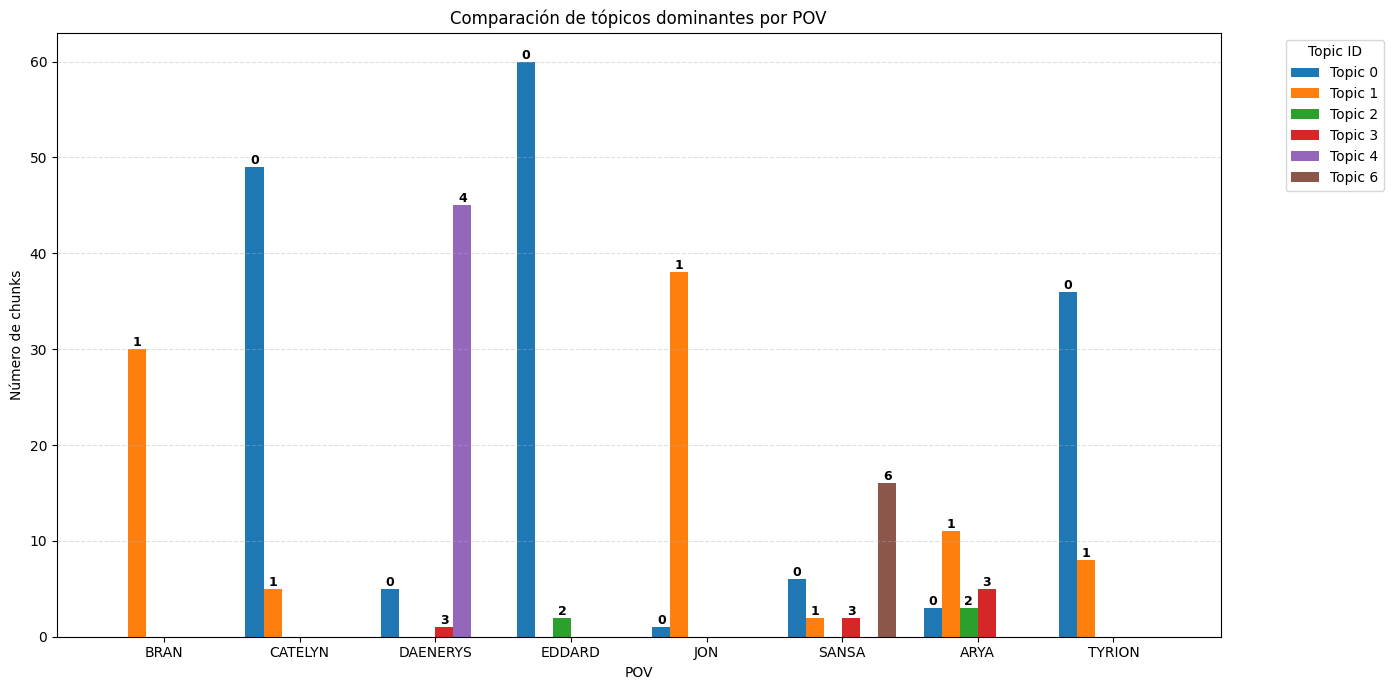

In [60]:
# =========================
# BARRAS AGRUPADAS:
# TOPICS DOMINANTES POR POV
# =========================

import numpy as np
import matplotlib.pyplot as plt

tabla_pov_topic_abs = (
    df_libro_topics
    .groupby(["pov", "topic_id"])
    .size()
    .unstack(fill_value=0)
)

orden_povs = [
    "BRAN",
    "CATELYN",
    "DAENERYS",
    "EDDARD",
    "JON",
    "SANSA",
    "ARYA",
    "TYRION"
]

tabla_pov_topic_abs = tabla_pov_topic_abs.reindex(orden_povs)

povs = tabla_pov_topic_abs.index.tolist()
topics = tabla_pov_topic_abs.columns.tolist()

x = np.arange(len(povs))
n_topics = len(topics)
width = 0.8 / n_topics

plt.figure(figsize=(14, 7))

for i, topic_id in enumerate(topics):
    valores = tabla_pov_topic_abs[topic_id].values

    posiciones = x - 0.4 + width / 2 + i * width

    plt.bar(
        posiciones,
        valores,
        width=width,
        label=f"Topic {topic_id}"
    )

    # Etiqueta del topic sobre cada barra
    for pos, valor in zip(posiciones, valores):
        if valor > 0:
            plt.text(
                pos,
                valor,
                str(topic_id),
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold"
            )

plt.xticks(x, povs, rotation=0)
plt.xlabel("POV")
plt.ylabel("Número de chunks")
plt.title("Comparación de tópicos dominantes por POV")

plt.legend(
    title="Topic ID",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Como podemos ver en la gráfica de arriba, vemos que Daenerys destaca especialmente porque es la única que tiene el Topic 4, además como dominante. Esto tiene muchisimo sentido porque Daenerys se encuentra en otro continente con una trama muy separada.

Por otro lado, vemos que Bran y Jon tienen el Topic 1 como el dominante (en el caso de Bran, solo tiene ese topic). Tiene sentido pues Bran y Jon Nieve son los personajes que se quedan en el Norte, uno en Invernalia y otro en el Muro, con tramas parecidas.

En cambio, Catelyn, Eddard y Tyrion tienen topics parecidos, pues son los personajes más importantes en lo que a la trama del Sur se refiere. Por ejemplo, Catelyn y Tyrion pasan mucho tiempo juntos. Eddard en cambio está en el Sur con todas las tramas políticas. Estas tramas son consecuencia de la decisión de Catelyn de atrapar a Tyrion.

Mientras tanto, Sansa y Arya tienen un surtido de Topics. Sansa destaca en el Topic 6, con presencia también del 0 (el de la política). Si bien Sansa es hija de Eddard y Catelyn, pasa más tiempo con los Lannister y tiene tramas "separadas" dentro de la trama del Sur. Arya, por otro lado, aparece de forma dispersa con Topics diferentes. Es la hermana que más relación tiene con Jon, lo que explicaría su presencia del Topic 1.

Podemos concluir que los Topics están más o menos bien repartidos y tienen sentido dentro del mundo del libro. Ahora, hagamos algo parecido con la colección de los resumenes. El problema es que en la colección de los resumenes no tenemos el POV de cada capítulo. No obstante, podemos inferirlo de la colección de los libros:

In [ ]:
# =========================
# INFERIR POV EN RESÚMENES
# A PARTIR DE df_libro
# =========================

# 1. Crear mapa chapter_order -> POV desde el libro
mapa_capitulo_pov = (
    df_libro[["chapter_order", "pov"]]
    .drop_duplicates()
    .set_index("chapter_order")["pov"]
    .to_dict()
)

# 2. Extraer número de capítulo en df_resumenes
def extraer_numero_capitulo_resumen(chapter):
    chapter = str(chapter)

    match = re.search(r"Capítulo\s+(\d+)", chapter)

    if match:
        return int(match.group(1))

    return np.nan  # Prólogo u otros casos sin número


df_resumenes_topics = df_resumenes.copy()

df_resumenes_topics["chapter_order"] = (
    df_resumenes_topics["chapter"]
    .apply(extraer_numero_capitulo_resumen)
)

# 3. Asignar POV inferido
df_resumenes_topics["pov_inferido"] = (
    df_resumenes_topics["chapter_order"]
    .map(mapa_capitulo_pov)
)

# Opcional: eliminar prólogo, porque no tiene POV equivalente en df_libro
df_resumenes_topics = df_resumenes_topics.dropna(subset=["pov_inferido"]).copy()

df_resumenes_topics[["chapter", "chapter_order", "pov_inferido"]].head(10)

,chapter,chapter_order,pov_inferido
2,Juego de Tronos-Capítulo 1,1.0,BRAN
3,Juego de Tronos-Capítulo 1,1.0,BRAN
4,Juego de Tronos-Capítulo 1,1.0,BRAN
5,Juego de Tronos-Capítulo 1,1.0,BRAN
6,Juego de Tronos-Capítulo 1,1.0,BRAN
7,Juego de Tronos-Capítulo 10,10.0,JON
8,Juego de Tronos-Capítulo 10,10.0,JON
9,Juego de Tronos-Capítulo 11,11.0,DAENERYS
10,Juego de Tronos-Capítulo 11,11.0,DAENERYS
11,Juego de Tronos-Capítulo 11,11.0,DAENERYS


In [62]:
# =========================
# TÓPICO DOMINANTE EN RESÚMENES
# =========================

def obtener_topico_dominante(modelo, corpus):
    resultados = []

    for i, bow in enumerate(corpus):
        distribucion = modelo.get_document_topics(
            bow,
            minimum_probability=0.0
        )

        topic_id, topic_prob = max(distribucion, key=lambda x: x[1])

        resultados.append({
            "doc_idx": i,
            "topic_id": topic_id,
            "topic_prob": topic_prob
        })

    return pd.DataFrame(resultados)


df_topics_resumenes = obtener_topico_dominante(
    lda_model_resumenes,
    corpus_resumenes_clean
)

df_resumenes_topics_full = df_resumenes.copy()
df_resumenes_topics_full["topic_id"] = df_topics_resumenes["topic_id"]
df_resumenes_topics_full["topic_prob"] = df_topics_resumenes["topic_prob"]

df_resumenes_topics_full["chapter_order"] = (
    df_resumenes_topics_full["chapter"]
    .apply(extraer_numero_capitulo_resumen)
)

df_resumenes_topics_full["pov_inferido"] = (
    df_resumenes_topics_full["chapter_order"]
    .map(mapa_capitulo_pov)
)

# Quitamos el prólogo
df_resumenes_topics_full = (
    df_resumenes_topics_full
    .dropna(subset=["pov_inferido"])
    .copy()
)

df_resumenes_topics_full[[
    "chapter",
    "chapter_order",
    "pov_inferido",
    "topic_id",
    "topic_prob"
]].head()

,chapter,chapter_order,pov_inferido,topic_id,topic_prob
2,Juego de Tronos-Capítulo 1,1.0,BRAN,0,0.992958
3,Juego de Tronos-Capítulo 1,1.0,BRAN,0,0.615799
4,Juego de Tronos-Capítulo 1,1.0,BRAN,0,0.987124
5,Juego de Tronos-Capítulo 1,1.0,BRAN,0,0.988258
6,Juego de Tronos-Capítulo 1,1.0,BRAN,0,0.982944


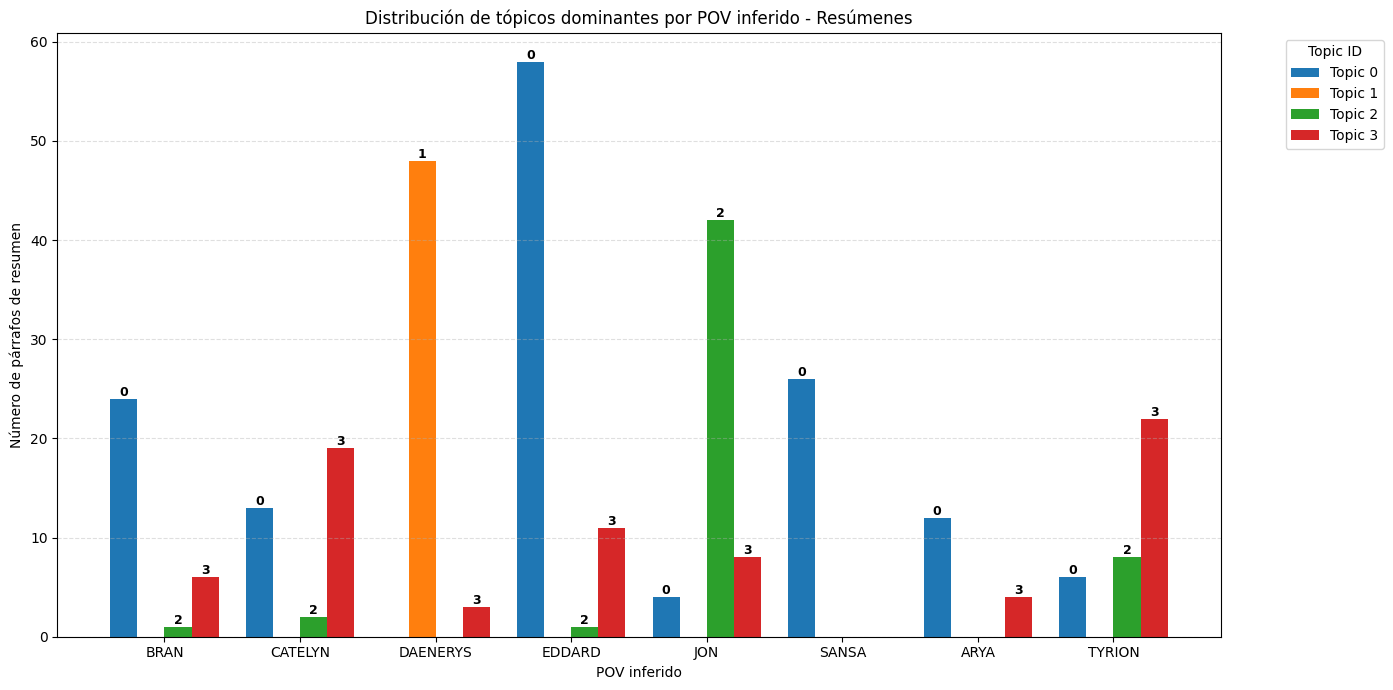

In [63]:
# =========================
# BARRAS AGRUPADAS:
# TOPICS DOMINANTES POR POV INFERIDO EN RESÚMENES
# =========================

tabla_pov_topic_resumenes = (
    df_resumenes_topics_full
    .groupby(["pov_inferido", "topic_id"])
    .size()
    .unstack(fill_value=0)
)

orden_povs = [
    "BRAN",
    "CATELYN",
    "DAENERYS",
    "EDDARD",
    "JON",
    "SANSA",
    "ARYA",
    "TYRION"
]

tabla_pov_topic_resumenes = tabla_pov_topic_resumenes.reindex(orden_povs)

povs = tabla_pov_topic_resumenes.index.tolist()
topics = tabla_pov_topic_resumenes.columns.tolist()

x = np.arange(len(povs))
n_topics = len(topics)
width = 0.8 / n_topics

plt.figure(figsize=(14, 7))

for i, topic_id in enumerate(topics):
    valores = tabla_pov_topic_resumenes[topic_id].values
    posiciones = x - 0.4 + width / 2 + i * width

    plt.bar(
        posiciones,
        valores,
        width=width,
        label=f"Topic {topic_id}"
    )

    for pos, valor in zip(posiciones, valores):
        if valor > 0:
            plt.text(
                pos,
                valor,
                str(topic_id),
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold"
            )

plt.xticks(x, povs, rotation=0)
plt.xlabel("POV inferido")
plt.ylabel("Número de párrafos de resumen")
plt.title("Distribución de tópicos dominantes por POV inferido - Resúmenes")

plt.legend(
    title="Topic ID",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Al igual que antes, Daenerys es la única con un Topic único, el 1 en este caso. Como antes, esto tiene mucho sentido.

Por otro lado, Eddard, Bran, Sansa Y Arya (los Stark verdaderos), tienen como Topic dominante el 0

Jon por otro lado tiene como dominante el 2, pues es el que está en el muro. Tyrion comparte parte del 2 con él porque en su viaje al muro, Tyrion acompaña a Jon y se hacen amigos.

Finalmente, Tyrion y Catelyn comparten el Topic 3 como principal por lo comentado anteriormente de que comparten mucho tiempo juntos.

Nuevamente, aunque con menos Topics, tienen sentido como están distribuidos.